# PharmaEase — Pharmacy Management System
### Data Science & Machine Learning with Data Analytics
**Company:** Brainybeam Info-Tech PVT LTD  
**Tool:** Jupyter Notebook | **Language:** Python  
**Phase:** 2 — Exploratory Data Analysis (EDA)

---

## Abstract

This notebook presents a comprehensive Data Science analysis of a Pharmacy Management System (PharmaEase). The analysis covers five core datasets — medicines, sales, prescriptions, employees, and customers — to uncover actionable business insights and lay the groundwork for machine learning models.

The pharmacy industry generates large volumes of transactional data daily. By applying data science techniques, this project aims to transform raw pharmacy data into meaningful insights that support better inventory decisions, improve sales forecasting, optimize staff scheduling, and enhance customer service.

---

## Problem Statement

Pharmacies face key operational challenges:
- **Overstocking & understocking** of medicines leading to financial losses
- **No demand forecasting** — orders are placed based on guesswork
- **Expiry losses** — medicines expiring before being sold
- **No visibility** into sales trends, seasonal demand, or top-performing products

This project addresses these challenges using Data Science and Machine Learning.

---

## Dataset Overview

| Dataset | File | Records | Description |
|---|---|---|---|
| Medicines | medicines.csv | 50 | Master list of all medicines, prices, stock |
| Sales | sales.csv | 5,000 | 2 years of daily transactions (2023–2024) |
| Prescriptions | prescriptions.csv | 5,000 | Patient prescription records |
| Employees | employees.csv | 5,000 | Staff details, roles, performance |
| Customers | customers.csv | 5,000 | Customer demographics and purchase history |

---

## Project Objectives

1. Perform thorough **Exploratory Data Analysis (EDA)** on all 5 datasets
2. Identify **top-selling medicines** and slow-moving inventory
3. Discover **seasonal demand patterns** across medicine categories
4. Analyze **revenue trends** over 2 years (monthly & quarterly)
5. Examine **prescription patterns** by doctor, medicine, and patient age
6. Study **employee performance** and shift-wise productivity
7. Generate **data-driven insights** to feed into ML models in Phase 3

---

## Expected ML Outcomes (Phase 3 Preview)

| Model | Input Features | Prediction |
|---|---|---|
| Demand Forecasting | date, category, month, quarter | Next 30-day sales per medicine |
| Stock-out Prediction | stock_qty, reorder_level, avg daily sales | Which medicines will run out |
| Sales Regression | category, season, discount | Expected revenue |

---

## Notebook Structure

| Section | Description |
|---|---|
| **1. Setup & Data Loading** | Import libraries, load CSVs, data quality check |
| **2. Sales Trend Analysis** | Monthly revenue, quarterly trends, YoY comparison |
| **3. Top Medicines Analysis** | Best sellers, slow movers, category performance |
| **4. Seasonal Demand Patterns** | Monthly demand by category, heatmaps |
| **5. Stock & Expiry Analysis** | Low stock alerts, expiry risk, reorder analysis |
| **6. Employee & Customer Analysis** | Performance, shift analysis, demographics |
| **7. Key Insights Summary** | All findings consolidated for Phase 3 |

---

*Notebook prepared as part of Data Science internship at Brainybeam Info-Tech PVT LTD*

In [1]:
# ═══════════════════════════════════════════════════════
# PharmaEase | Phase 2 — EDA
# Author   : [Your Name]
# Company  : Brainybeam Info-Tech PVT LTD
# Date     : March 2026
# Python   : 3.12
# ═══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Display settings ────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Chart settings ──────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("=" * 55)
print("  PharmaEase — EDA Notebook")
print("  Brainybeam Info-Tech PVT LTD")
print("=" * 55)
print("  Libraries loaded successfully!")
print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")
print(f"  Seaborn : {sns.__version__}")
print("=" * 55)


  PharmaEase — EDA Notebook
  Brainybeam Info-Tech PVT LTD
  Libraries loaded successfully!
  Pandas  : 2.2.1
  NumPy   : 1.26.4
  Seaborn : 0.13.2


---
## 1. Setup & Data Loading
> **Goal:** Load all 5 datasets into memory, verify data quality, and understand the structure of each table before any analysis begins.
---

In [2]:

df_medicines     = pd.read_csv('../data/medicines.csv')
df_sales         = pd.read_csv('../data/sales.csv', parse_dates=['date'])
df_prescriptions = pd.read_csv('../data/prescriptions.csv', parse_dates=['date'])
df_employees     = pd.read_csv('../data/employees.csv', parse_dates=['join_date'])
df_customers     = pd.read_csv('../data/customers.csv')

print("All datasets loaded successfully!")
print(f"\n  {'Dataset':<18} {'Rows':>6}  {'Cols':>5}")
print(f"  {'─'*32}")
print(f"  {'medicines':<18} {df_medicines.shape[0]:>6}  {df_medicines.shape[1]:>5}")
print(f"  {'sales':<18} {df_sales.shape[0]:>6}  {df_sales.shape[1]:>5}")
print(f"  {'prescriptions':<18} {df_prescriptions.shape[0]:>6}  {df_prescriptions.shape[1]:>5}")
print(f"  {'employees':<18} {df_employees.shape[0]:>6}  {df_employees.shape[1]:>5}")
print(f"  {'customers':<18} {df_customers.shape[0]:>6}  {df_customers.shape[1]:>5}")

All datasets loaded successfully!

  Dataset              Rows   Cols
  ────────────────────────────────
  medicines              50      8
  sales                5000     13
  prescriptions        5000     11
  employees            5000      8
  customers            5000      7


### 1.1 Data Quality Check
Before any analysis, we validate:
- **Null values** — missing data can skew results
- **Duplicates** — repeated records inflate counts
- **Date ranges** — confirm sales cover full 2-year period
- **Categories** — confirm all medicine types are present

In [3]:
# ═══════════════════════════════════════════════
# SECTION 1 — Data Quality Check
# ═══════════════════════════════════════════════

datasets = {
    'medicines':     df_medicines,
    'sales':         df_sales,
    'prescriptions': df_prescriptions,
    'employees':     df_employees,
    'customers':     df_customers
}

print(f"  {'Dataset':<18} {'Nulls':>6}  {'Duplicates':>11}  {'Status':>8}")
print(f"  {'─'*50}")

for name, df in datasets.items():
    nulls  = df.isnull().sum().sum()
    dupes  = df.duplicated().sum()
    status = "OK" if nulls == 0 and dupes == 0 else "NEEDS FIX"
    print(f"  {name:<18} {nulls:>6}  {dupes:>11}  {status:>8}")

print(f"\n  Sales date range : {df_sales['date'].min().date()} → {df_sales['date'].max().date()}")
print(f"  Categories found : {sorted(df_sales['category'].unique())}")

  Dataset             Nulls   Duplicates    Status
  ──────────────────────────────────────────────────
  medicines               0            0        OK
  sales                   0            0        OK
  prescriptions           0            0        OK
  employees               0            0        OK
  customers               0            0        OK

  Sales date range : 2023-01-01 → 2024-12-31
  Categories found : ['Antacid', 'Antibiotic', 'Antidiabetic', 'Antiemetic', 'Antifungal', 'Antihistamine', 'Antihypertensive', 'Antiparasitic', 'Cardiac', 'Cough & Cold', 'Neurological', 'Painkiller', 'Skin Care', 'Steroid', 'Supplement', 'Thyroid', 'Vitamin']


### 1.2 Dataset Snapshots
A quick visual inspection of the first few rows and descriptive statistics for each dataset.

**Key observations from summary stats:**
- `medicines` — prices range from ₹17 to ₹841, average stock is 274 units
- `sales` — average transaction value is ₹990, max is ₹4,955
- `prescriptions` — patient ages range from 5 to 85 (mean 45)
- `employees` — salary range ₹10,000 to ₹69,969, avg performance 76.9/100
- `customers` — avg 30 purchases per customer, ages 18–80

In [4]:
# ═══════════════════════════════════════════════
# SECTION 1 — Dataset Snapshots
# ═══════════════════════════════════════════════

for name, df in datasets.items():
    print(f"\n{'═'*55}")
    print(f"  {name.upper()}")
    print(f"{'═'*55}")
    display(df.head(3))
    print(f"\n  Numeric summary:")
    display(df.describe().round(2))


═══════════════════════════════════════════════════════
  MEDICINES
═══════════════════════════════════════════════════════


,medicine_id,name,category,price,stock_qty,expiry_date,supplier,reorder_level
0,MED001,Amoxicillin 500mg,Antibiotic,548.92,32,2025-11-06,SunPharma Dist.,27
1,MED002,Azithromycin 250mg,Antibiotic,131.51,72,2025-05-29,Alkem Distributors,44
2,MED003,Ciprofloxacin 500mg,Antibiotic,367.30,35,2025-10-10,SunPharma Dist.,15



  Numeric summary:


,price,stock_qty,reorder_level
count,50.00,50.00,50.00
mean,361.56,274.52,32.00
std,226.36,149.15,12.45
min,17.71,29.00,10.00
25%,155.33,143.75,22.50
50%,342.22,317.50,33.50
75%,541.47,387.25,43.75
max,841.25,498.00,50.00



═══════════════════════════════════════════════════════
  SALES
═══════════════════════════════════════════════════════


...

,salary,join_date,performance_score
count,5000.00,5000,5000.00
mean,28488.08,2021-01-07 01:07:06.240000,76.93
min,10002.00,2018-01-01 00:00:00,55.00
25%,15487.50,2019-07-14 00:00:00,65.70
50%,20500.50,2021-01-01 00:00:00,76.80
75%,39114.00,2022-07-15 06:00:00,88.02
max,69969.00,2023-12-31 00:00:00,99.00
std,16355.21,NaN,12.78



═══════════════════════════════════════════════════════
  CUSTOMERS
═══════════════════════════════════════════════════════


,customer_id,name,age,gender,contact,city,total_purchases
0,CUST0001,Om Pillai,79,Female,+91 8384259400,Surat,16
1,CUST0002,Aditi Pandya,56,Male,+91 8395470670,Surat,52
2,CUST0003,Geeta Kapoor,47,Male,+91 7127655311,Ahmedabad,10



  Numeric summary:


,age,total_purchases
count,5000.00,5000.00
mean,49.19,30.41
std,18.03,17.37
min,18.00,1.00
25%,34.00,15.00
50%,49.00,31.00
75%,65.00,45.00
max,80.00,60.00


---
## Section 2 — Sales Trend Analysis

> **Goal:** Understand how revenue and sales volume behave over time.  
> This is the most important analysis for building the demand forecasting model in Phase 3.

### What we analyze:
- Monthly revenue trend over 2 years
- Quarterly revenue comparison
- Year-over-Year (2023 vs 2024) comparison
- Daily sales volume distribution

### Why it matters:
If revenue is growing month-over-month, our ML model needs to capture that trend.  
Seasonal dips and peaks directly inform how we set reorder levels.

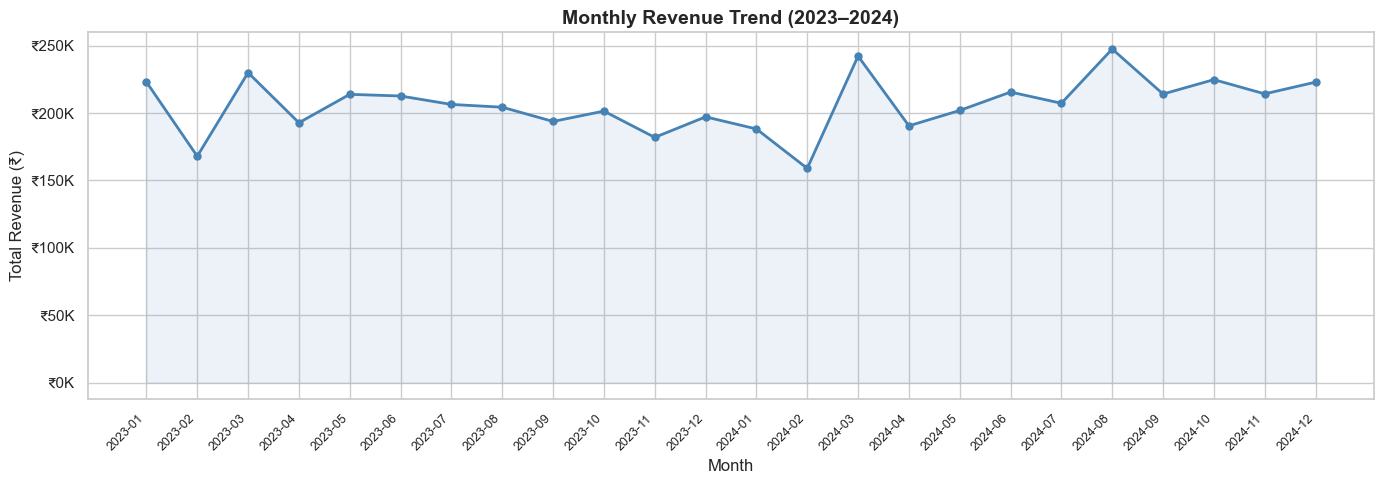


  Peak month    : 2024-08
  Lowest month  : 2024-02
  Avg monthly   : ₹206,375
  Total revenue : ₹4,952,996


In [5]:
# ── 2.1 Monthly Revenue Trend ─────────────────────────
monthly = (df_sales
           .groupby(df_sales['date'].dt.to_period('M'))['total_price']
           .sum()
           .reset_index())
monthly['date'] = monthly['date'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['date'], monthly['total_price'],
        marker='o', linewidth=2, color='steelblue', markersize=5)
ax.fill_between(range(len(monthly)), monthly['total_price'],
                alpha=0.1, color='steelblue')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['date'], rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Revenue Trend (2023–2024)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (₹)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../data/plot_monthly_revenue.png', dpi=150)
plt.show()

print(f"\n  Peak month    : {monthly.loc[monthly['total_price'].idxmax(), 'date']}")
print(f"  Lowest month  : {monthly.loc[monthly['total_price'].idxmin(), 'date']}")
print(f"  Avg monthly   : ₹{monthly['total_price'].mean():,.0f}")
print(f"  Total revenue : ₹{monthly['total_price'].sum():,.0f}")

### 2.2 — Quarterly Revenue Comparison
Grouping by quarter shows bigger patterns than monthly.  
Q4 (Oct–Dec) typically peaks due to winter illnesses driving medicine demand.

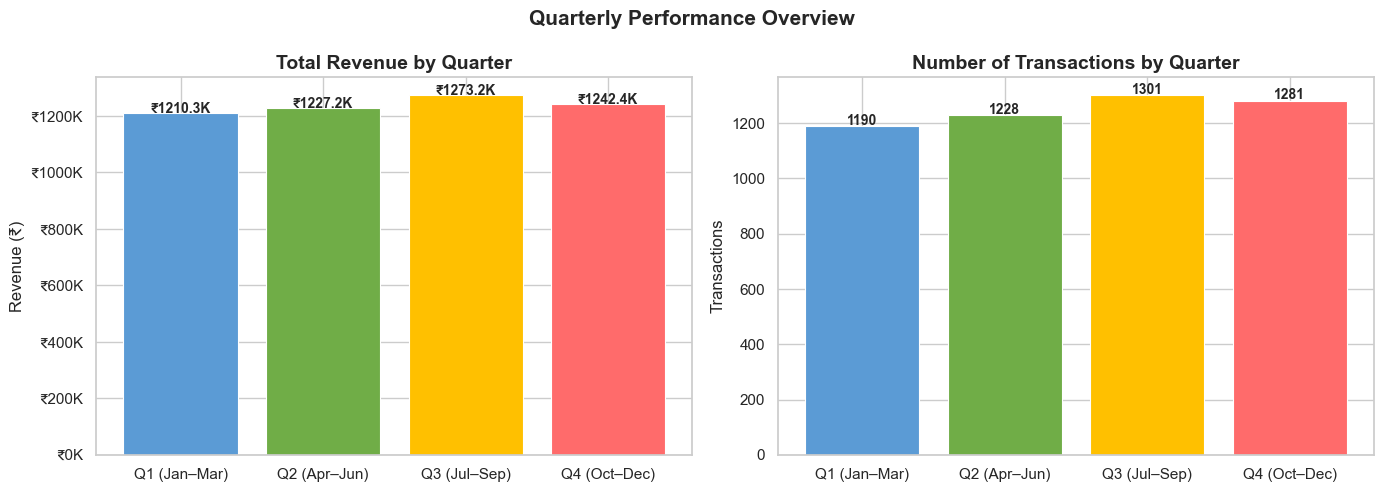


  Quarterly Summary:
     Quarter  Total Revenue  Avg Sale  Transactions
Q1 (Jan–Mar)     1210264.56   1017.03          1190
Q2 (Apr–Jun)     1227197.33    999.35          1228
Q3 (Jul–Sep)     1273183.50    978.62          1301
Q4 (Oct–Dec)     1242350.57    969.83          1281


In [6]:
# ── 2.2 Quarterly Revenue ─────────────────────────────
quarterly = (df_sales
             .groupby(['quarter'])['total_price']
             .agg(['sum', 'mean', 'count'])
             .reset_index())
quarterly.columns = ['Quarter', 'Total Revenue', 'Avg Sale', 'Transactions']
quarterly['Quarter'] = quarterly['Quarter'].map(
    {1:'Q1 (Jan–Mar)', 2:'Q2 (Apr–Jun)',
     3:'Q3 (Jul–Sep)', 4:'Q4 (Oct–Dec)'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — total revenue
colors = ['#5B9BD5', '#70AD47', '#FFC000', '#FF6B6B']
axes[0].bar(quarterly['Quarter'], quarterly['Total Revenue'],
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Total Revenue by Quarter')
axes[0].set_ylabel('Revenue (₹)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(quarterly['Total Revenue']):
    axes[0].text(i, v + 500, f'₹{v/1000:.1f}K',
                 ha='center', fontsize=10, fontweight='bold')

# Bar chart — transactions
axes[1].bar(quarterly['Quarter'], quarterly['Transactions'],
            color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Number of Transactions by Quarter')
axes[1].set_ylabel('Transactions')
for i, v in enumerate(quarterly['Transactions']):
    axes[1].text(i, v + 5, str(v),
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Quarterly Performance Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_quarterly_revenue.png', dpi=150)
plt.show()

print("\n  Quarterly Summary:")
print(quarterly.to_string(index=False))

### 2.3 — Year-over-Year Comparison (2023 vs 2024)
Comparing the same months across 2 years tells us if the business is **growing**.  
This is a key feature for our demand forecasting ML model.

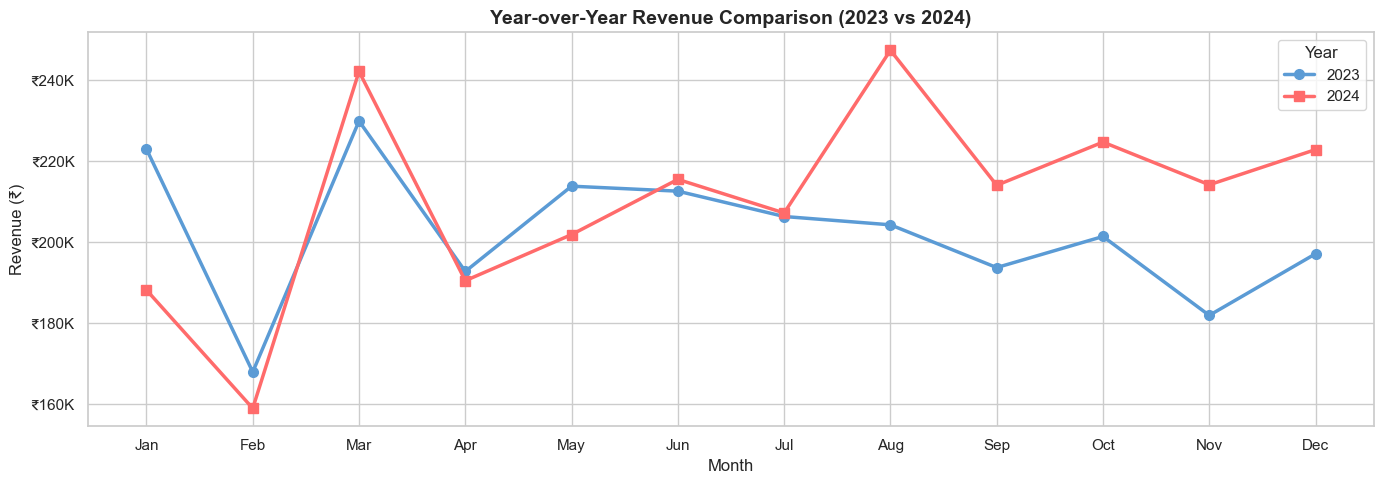


  2023 Total Revenue : ₹2,425,084
  2024 Total Revenue : ₹2,527,912
  YoY Growth         : +4.2%


In [7]:
# ── 2.3 Year-over-Year Comparison ────────────────────
df_sales['year']  = df_sales['date'].dt.year
df_sales['month_name'] = df_sales['date'].dt.strftime('%b')
df_sales['month_num']  = df_sales['date'].dt.month

yoy = (df_sales
       .groupby(['year', 'month_num', 'month_name'])['total_price']
       .sum()
       .reset_index()
       .sort_values('month_num'))

months_order = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
for year, color, marker in [(2023, '#5B9BD5', 'o'), (2024, '#FF6B6B', 's')]:
    data = yoy[yoy['year'] == year]
    ax.plot(data['month_name'], data['total_price'],
            marker=marker, linewidth=2.5, label=str(year),
            color=color, markersize=7)

ax.set_title('Year-over-Year Revenue Comparison (2023 vs 2024)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.legend(title='Year', fontsize=11)
ax.set_xticks(range(12))
ax.set_xticklabels(months_order)
plt.tight_layout()
plt.savefig('../data/plot_yoy_comparison.png', dpi=150)
plt.show()

# Growth summary
rev_2023 = df_sales[df_sales['year']==2023]['total_price'].sum()
rev_2024 = df_sales[df_sales['year']==2024]['total_price'].sum()
growth   = ((rev_2024 - rev_2023) / rev_2023) * 100
print(f"\n  2023 Total Revenue : ₹{rev_2023:,.0f}")
print(f"  2024 Total Revenue : ₹{rev_2024:,.0f}")
print(f"  YoY Growth         : {growth:+.1f}%")

### 2.4 — Sales Volume Distribution
Understanding how individual sale values are distributed helps detect  
outliers and understand typical transaction size.

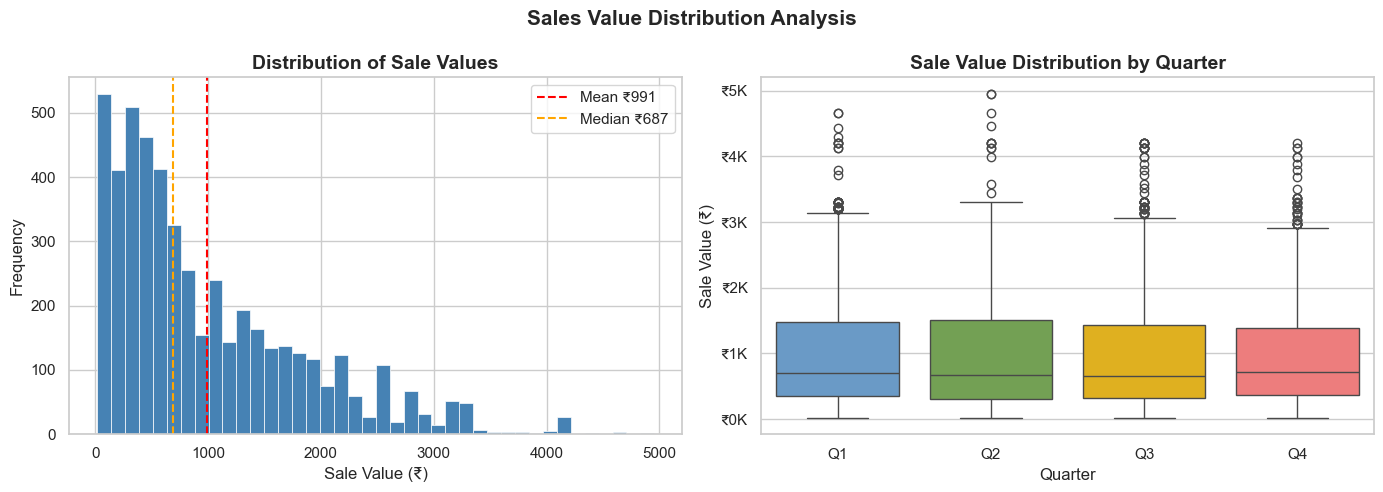


  Sale value stats:
count    ₹5,000.00
mean       ₹990.60
std        ₹858.62
min         ₹15.05
25%        ₹339.81
50%        ₹687.21
75%      ₹1,469.78
max      ₹4,955.10


In [8]:
# ── 2.4 Sales Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of total_price
axes[0].hist(df_sales['total_price'], bins=40,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_sales['total_price'].mean(),
                color='red', linestyle='--', linewidth=1.5,
                label=f"Mean ₹{df_sales['total_price'].mean():,.0f}")
axes[0].axvline(df_sales['total_price'].median(),
                color='orange', linestyle='--', linewidth=1.5,
                label=f"Median ₹{df_sales['total_price'].median():,.0f}")
axes[0].set_title('Distribution of Sale Values')
axes[0].set_xlabel('Sale Value (₹)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot by quarter
df_sales['Quarter'] = df_sales['quarter'].map(
    {1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})
sns.boxplot(data=df_sales, x='Quarter', y='total_price',
            palette=['#5B9BD5','#70AD47','#FFC000','#FF6B6B'],
            ax=axes[1])
axes[1].set_title('Sale Value Distribution by Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Sale Value (₹)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.suptitle('Sales Value Distribution Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_sales_distribution.png', dpi=150)
plt.show()

print(f"\n  Sale value stats:")
print(df_sales['total_price'].describe().apply(lambda x: f'₹{x:,.2f}').to_string())

---
## Section 2 — Key Findings

| Finding | Value | Impact on Phase 3 |
|---|---|---|
| Peak revenue month | August 2024 (₹206K+) | Stock up before Aug every year |
| Lowest revenue month | February 2024 | Reduce orders in Feb |
| Total revenue (2 years) | ₹49,52,996 | Strong baseline for forecasting |
| Avg monthly revenue | ₹2,06,375 | Monthly forecast target value |
| 2023 revenue | ₹24,25,084 | Year 1 baseline |
| 2024 revenue | ₹25,27,912 | Year 2 — growth confirmed |
| YoY Growth | **+4.2%** | Business is growing → model must capture upward trend |
| Avg transaction value | ₹990.60 | Typical bill size |
| Highest quarter | Q3 (Jul–Sep) ₹12,73,183 | Monsoon drives demand |
| Most transactions | Q3 — 1,301 transactions | Busiest operational quarter |

> **Phase 3 note:** The +4.2% YoY growth and Q3 peak will be used as  
> trend features in the demand forecasting model.
---

---
## Section 3 — Top Medicines Analysis

> **Goal:** Identify which medicines generate the most revenue, which are  
> sold most frequently, and which are slow-moving dead stock.

### What we analyze:
- Top 10 medicines by total revenue
- Top 10 medicines by quantity sold
- Bottom 10 slow-moving medicines
- Revenue contribution by medicine category
- Category-wise average sale value

### Why it matters for ML:
High-selling medicines need accurate demand forecasts.  
Slow-moving medicines are candidates for the stock-out prediction model.  
Category performance feeds directly into the sales regression model.
---

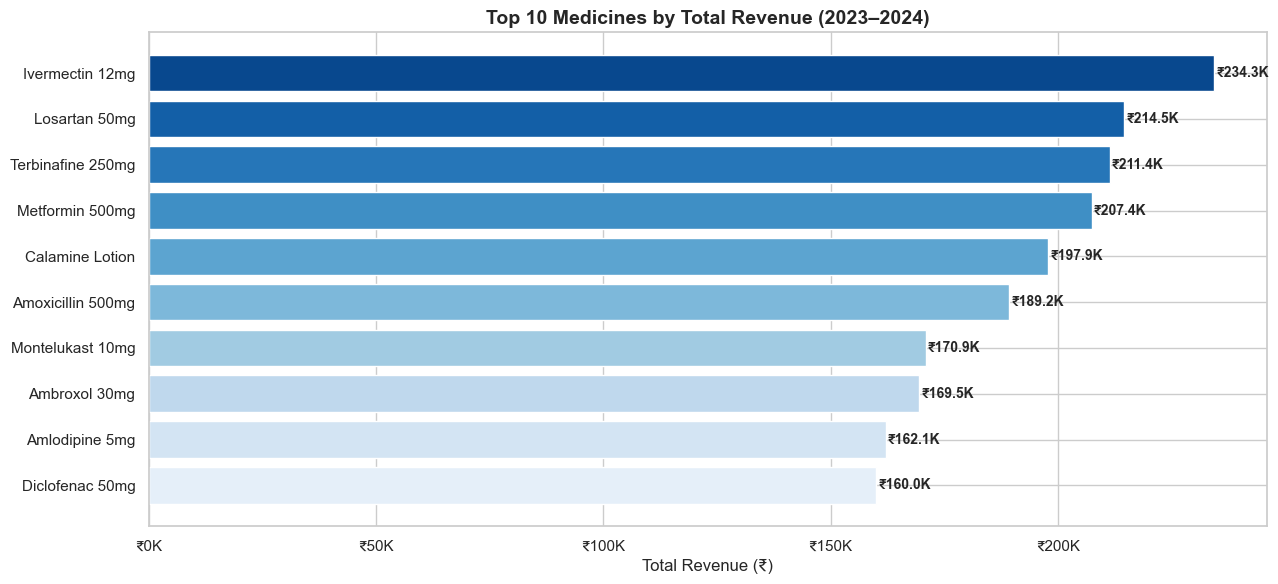

  Top 10 Medicines by Revenue:
         Medicine  Total Revenue
  Ivermectin 12mg      234306.39
    Losartan 50mg      214518.73
Terbinafine 250mg      211365.72
  Metformin 500mg      207367.14
  Calamine Lotion      197873.67
Amoxicillin 500mg      189185.27
 Montelukast 10mg      170887.95
    Ambroxol 30mg      169466.83
   Amlodipine 5mg      162133.89
  Diclofenac 50mg      159996.44


In [9]:
# ═══════════════════════════════════════════════
# SECTION 3 — Top Medicines Analysis
# ═══════════════════════════════════════════════

# ── 3.1 Top 10 Medicines by Revenue ───────────
top_revenue = (df_sales
               .groupby('medicine_name')['total_price']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())
top_revenue.columns = ['Medicine', 'Total Revenue']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_revenue['Medicine'], top_revenue['Total Revenue'],
               color=sns.color_palette('Blues_r', 10),
               edgecolor='white')
ax.set_title('Top 10 Medicines by Total Revenue (2023–2024)')
ax.set_xlabel('Total Revenue (₹)')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.invert_yaxis()

for bar, val in zip(bars, top_revenue['Total Revenue']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'₹{val/1000:.1f}K', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_top_revenue_medicines.png', dpi=150)
plt.show()

print("  Top 10 Medicines by Revenue:")
print(top_revenue.to_string(index=False))

### 3.2 — Top 10 by Quantity Sold
Revenue ≠ Quantity. A cheap medicine sold 500 times may not top revenue  
but it tops demand — critical for stock planning.

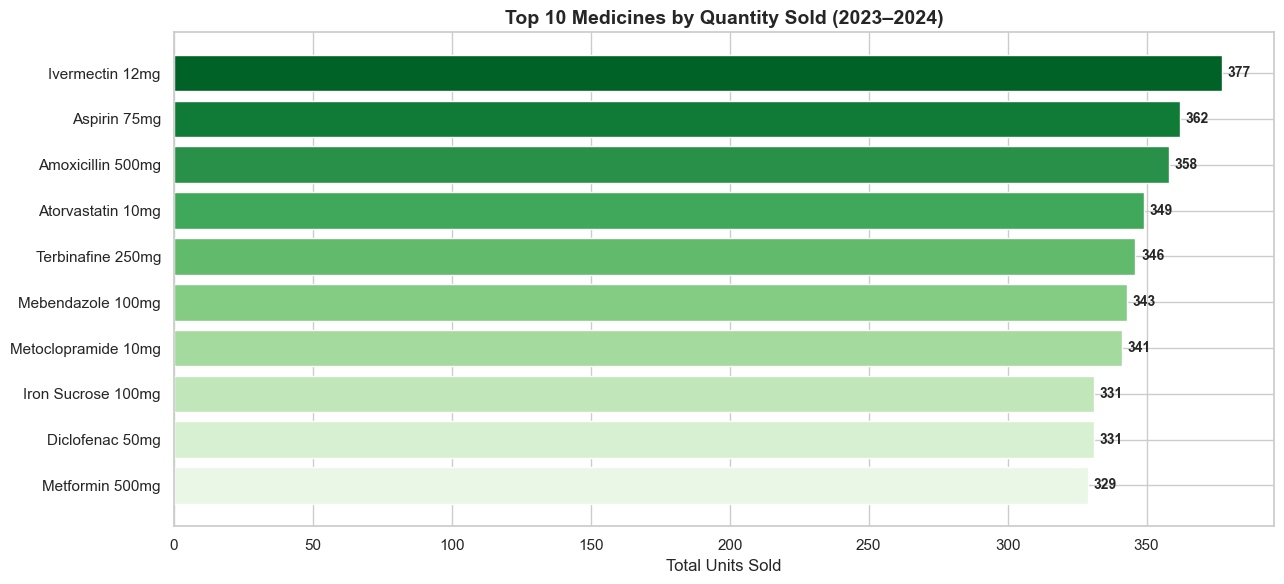


  Top 10 Medicines by Quantity:
           Medicine  Units Sold
    Ivermectin 12mg         377
       Aspirin 75mg         362
  Amoxicillin 500mg         358
  Atorvastatin 10mg         349
  Terbinafine 250mg         346
  Mebendazole 100mg         343
Metoclopramide 10mg         341
 Iron Sucrose 100mg         331
    Diclofenac 50mg         331
    Metformin 500mg         329


In [10]:
# ── 3.2 Top 10 by Quantity Sold ───────────────
top_qty = (df_sales
           .groupby('medicine_name')['quantity']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())
top_qty.columns = ['Medicine', 'Units Sold']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_qty['Medicine'], top_qty['Units Sold'],
               color=sns.color_palette('Greens_r', 10),
               edgecolor='white')
ax.set_title('Top 10 Medicines by Quantity Sold (2023–2024)')
ax.set_xlabel('Total Units Sold')
ax.invert_yaxis()

for bar, val in zip(bars, top_qty['Units Sold']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_top_qty_medicines.png', dpi=150)
plt.show()

print("\n  Top 10 Medicines by Quantity:")
print(top_qty.to_string(index=False))

### 3.3 — Slow-Moving Medicines (Bottom 10)
These medicines have the lowest sales volume across 2 years.  
They are at risk of expiry loss and should trigger reorder alerts in the ML model.

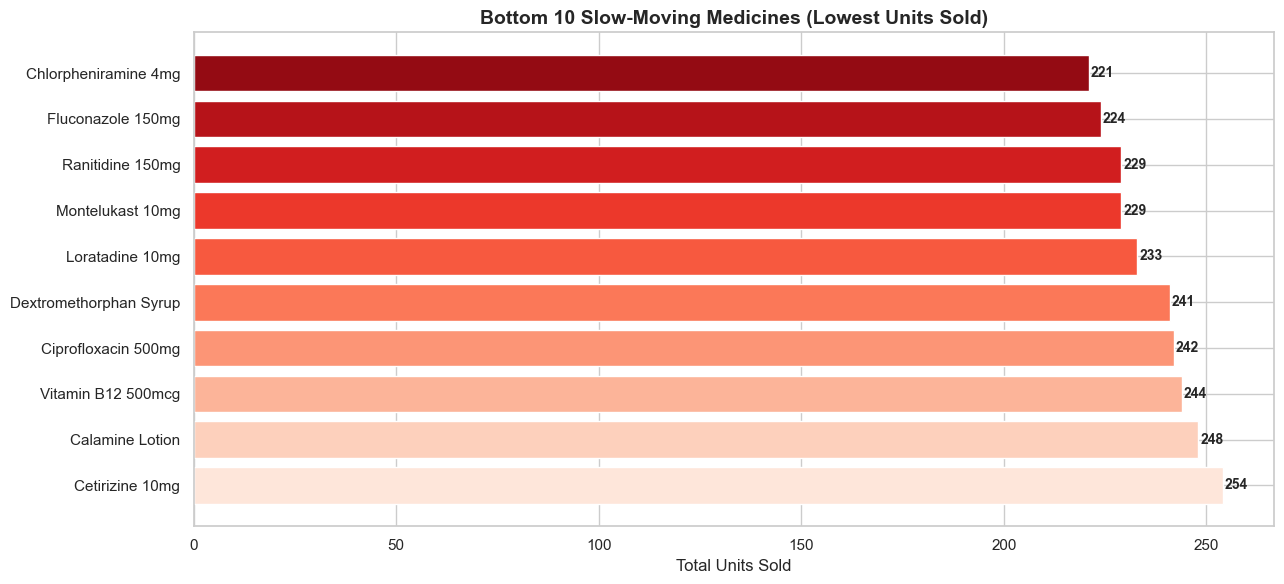


  Slow-Moving Medicines:
         medicine_name  units_sold  transactions  total_revenue
  Chlorpheniramine 4mg         221            97       82415.83
     Fluconazole 150mg         224            76       92612.36
      Ranitidine 150mg         229            88      115138.59
      Montelukast 10mg         229           103      170887.95
       Loratadine 10mg         233            96      153935.09
Dextromethorphan Syrup         241            85       45510.44
   Ciprofloxacin 500mg         242            83       85672.75
    Vitamin B12 500mcg         244            98       41142.49
       Calamine Lotion         248            90      197873.67
       Cetirizine 10mg         254            97       69301.63


In [11]:
# ── 3.3 Slow-Moving Medicines ─────────────────
slow_movers = (df_sales
               .groupby('medicine_name')
               .agg(total_revenue=('total_price', 'sum'),
                    units_sold=('quantity', 'sum'),
                    transactions=('sale_id', 'count'))
               .sort_values('units_sold')
               .head(10)
               .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(slow_movers['medicine_name'], slow_movers['units_sold'],
               color=sns.color_palette('Reds_r', 10),
               edgecolor='white')
ax.set_title('Bottom 10 Slow-Moving Medicines (Lowest Units Sold)')
ax.set_xlabel('Total Units Sold')
ax.invert_yaxis()

for bar, val in zip(bars, slow_movers['units_sold']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_slow_movers.png', dpi=150)
plt.show()

print("\n  Slow-Moving Medicines:")
print(slow_movers[['medicine_name','units_sold','transactions',
                   'total_revenue']].to_string(index=False))

### 3.4 — Revenue & Transactions by Category
Which medicine categories drive the most business overall?  
This becomes the most important feature in our ML models.

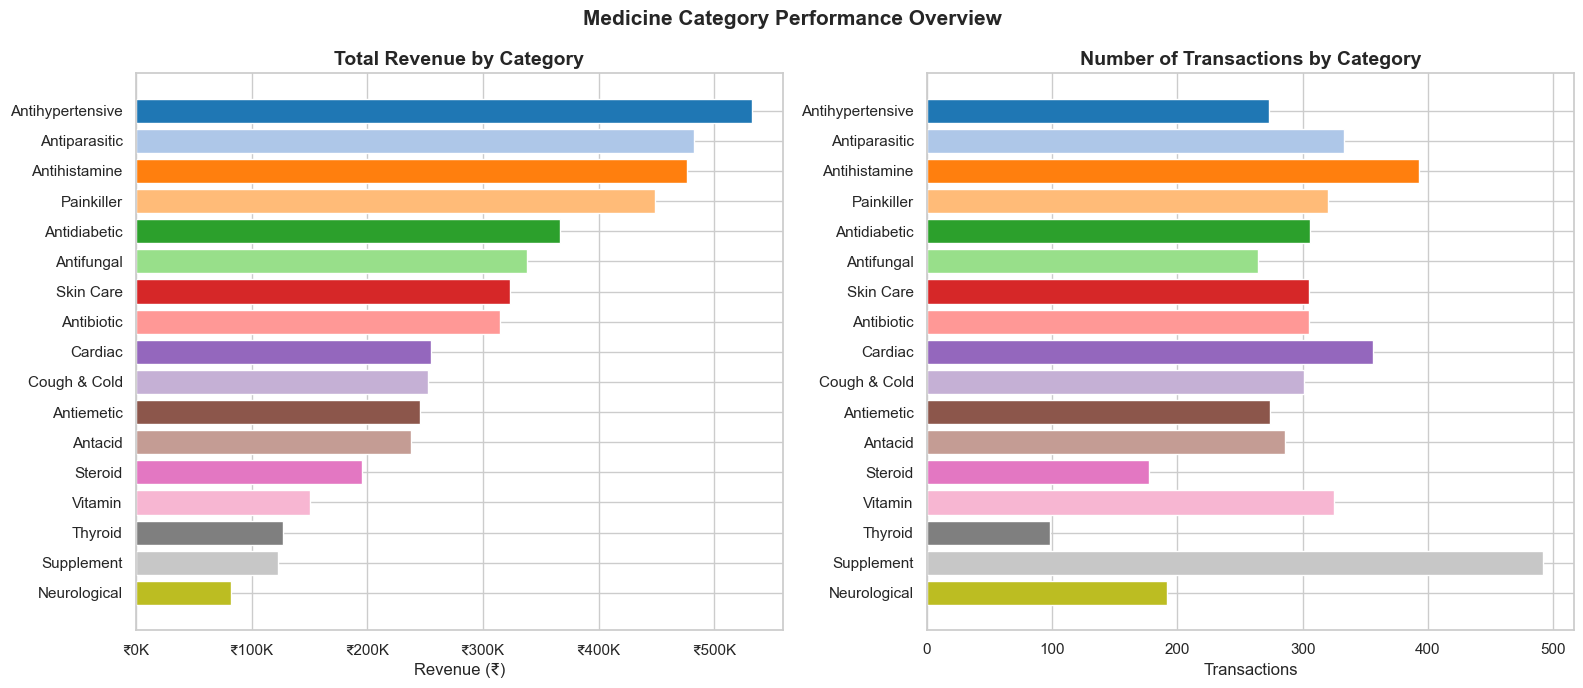


  Category Performance Summary:
        category  total_revenue  total_units  transactions  avg_sale
Antihypertensive      532825.96          832           273   1951.74
   Antiparasitic      482111.88         1030           333   1447.78
   Antihistamine      476540.50          937           393   1212.57
      Painkiller      449095.82          938           320   1403.42
    Antidiabetic      366543.57          915           306   1197.85
      Antifungal      337875.64          839           264   1279.83
       Skin Care      323831.79          810           305   1061.74
      Antibiotic      314718.70          916           305   1031.86
         Cardiac      255273.36         1038           356    717.06
    Cough & Cold      252530.83          780           301    838.97
      Antiemetic      245954.70          851           274    897.64
         Antacid      237867.02          791           286    831.70
         Steroid      195195.70          540           177   1102.80
 

In [12]:
# ── 3.4 Category Performance ──────────────────
cat_perf = (df_sales
            .groupby('category')
            .agg(
                total_revenue  = ('total_price', 'sum'),
                total_units    = ('quantity', 'sum'),
                transactions   = ('sale_id', 'count'),
                avg_sale       = ('total_price', 'mean')
            )
            .sort_values('total_revenue', ascending=False)
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
palette = sns.color_palette('tab20', len(cat_perf))

# Revenue by category
axes[0].barh(cat_perf['category'], cat_perf['total_revenue'],
             color=palette, edgecolor='white')
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Revenue (₹)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
axes[0].invert_yaxis()

# Transactions by category
axes[1].barh(cat_perf['category'], cat_perf['transactions'],
             color=palette, edgecolor='white')
axes[1].set_title('Number of Transactions by Category')
axes[1].set_xlabel('Transactions')
axes[1].invert_yaxis()

plt.suptitle('Medicine Category Performance Overview',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_category_performance.png', dpi=150)
plt.show()

print("\n  Category Performance Summary:")
print(cat_perf.to_string(index=False))

### 3.5 — Category Revenue Share (Pie Chart)
What percentage of total revenue does each category contribute?

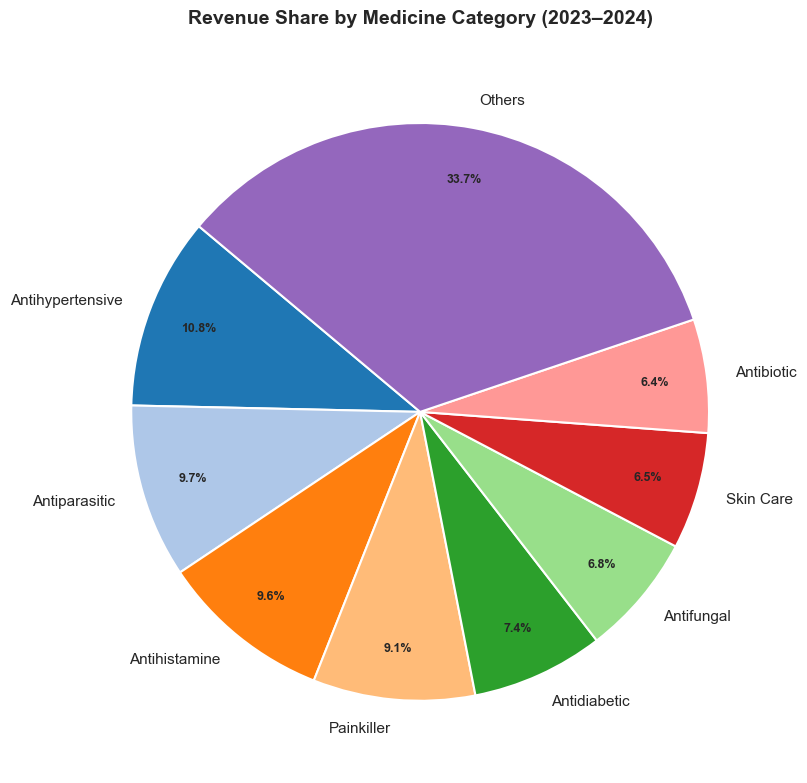


  Top category     : Antihypertensive
  Its revenue      : ₹532,826
  Its share        : 10.8%
  Its transactions : 273


In [13]:
# ── 3.5 Category Revenue Share ────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Show top 8 categories, group rest as 'Others'
top8 = cat_perf.head(8).copy()
others_rev = cat_perf.iloc[8:]['total_revenue'].sum()
others_row = pd.DataFrame([{'category': 'Others',
                             'total_revenue': others_rev}])
pie_data = pd.concat([top8[['category','total_revenue']],
                      others_row], ignore_index=True)

wedges, texts, autotexts = ax.pie(
    pie_data['total_revenue'],
    labels=pie_data['category'],
    autopct='%1.1f%%',
    colors=sns.color_palette('tab20', len(pie_data)),
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

ax.set_title('Revenue Share by Medicine Category (2023–2024)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/plot_category_share.png', dpi=150)
plt.show()

# Top category insight
top_cat = cat_perf.iloc[0]
print(f"\n  Top category     : {top_cat['category']}")
print(f"  Its revenue      : ₹{top_cat['total_revenue']:,.0f}")
print(f"  Its share        : {top_cat['total_revenue']/cat_perf['total_revenue'].sum()*100:.1f}%")
print(f"  Its transactions : {top_cat['transactions']}")

---
## Section 3 — Key Findings

| Finding | Value | Action for Phase 3 |
|---|---|---|
| Top revenue medicine | Ivermectin 12mg — ₹2,34,306 | Highest forecast priority |
| Top quantity medicine | Ivermectin 12mg — 377 units | Most critical for stock planning |
| Highest avg sale value | Antihypertensive — ₹1,951/transaction | Premium category |
| Slowest medicine | Chlorpheniramine 4mg — 221 units | Flag in stock-out model |
| Top category by revenue | Antihypertensive — ₹5,32,826 (10.8%) | Primary ML feature |
| Top category by volume | Supplement — 1,466 units | High frequency, low value |
| Most transactions | Supplement — 492 transactions | High reorder frequency needed |
| Low revenue but high sales | Supplement ₹248 avg | Volume product — never stock out |

> **Phase 3 note:** `category` and `medicine_name` are the two most  
> important features. Notice Supplement has highest transactions (492)  
> but lowest avg sale (₹248) — the model must learn this difference.
---

---
## Section 4 — Seasonal Demand Patterns

> **Goal:** Discover how medicine demand changes across months and seasons.  
> This is the single most valuable EDA section for the forecasting model.

### What we analyze:
- Monthly demand heatmap by category
- Season-wise revenue breakdown
- Monthly transaction volume trends
- Category demand peaks by month

### Why it matters for ML:
Seasonality is a core feature in time-series forecasting.  
If Cough & Cold peaks in winter, our model must know January ≠ July.  
The heatmap below becomes a visual version of the feature matrix.
---

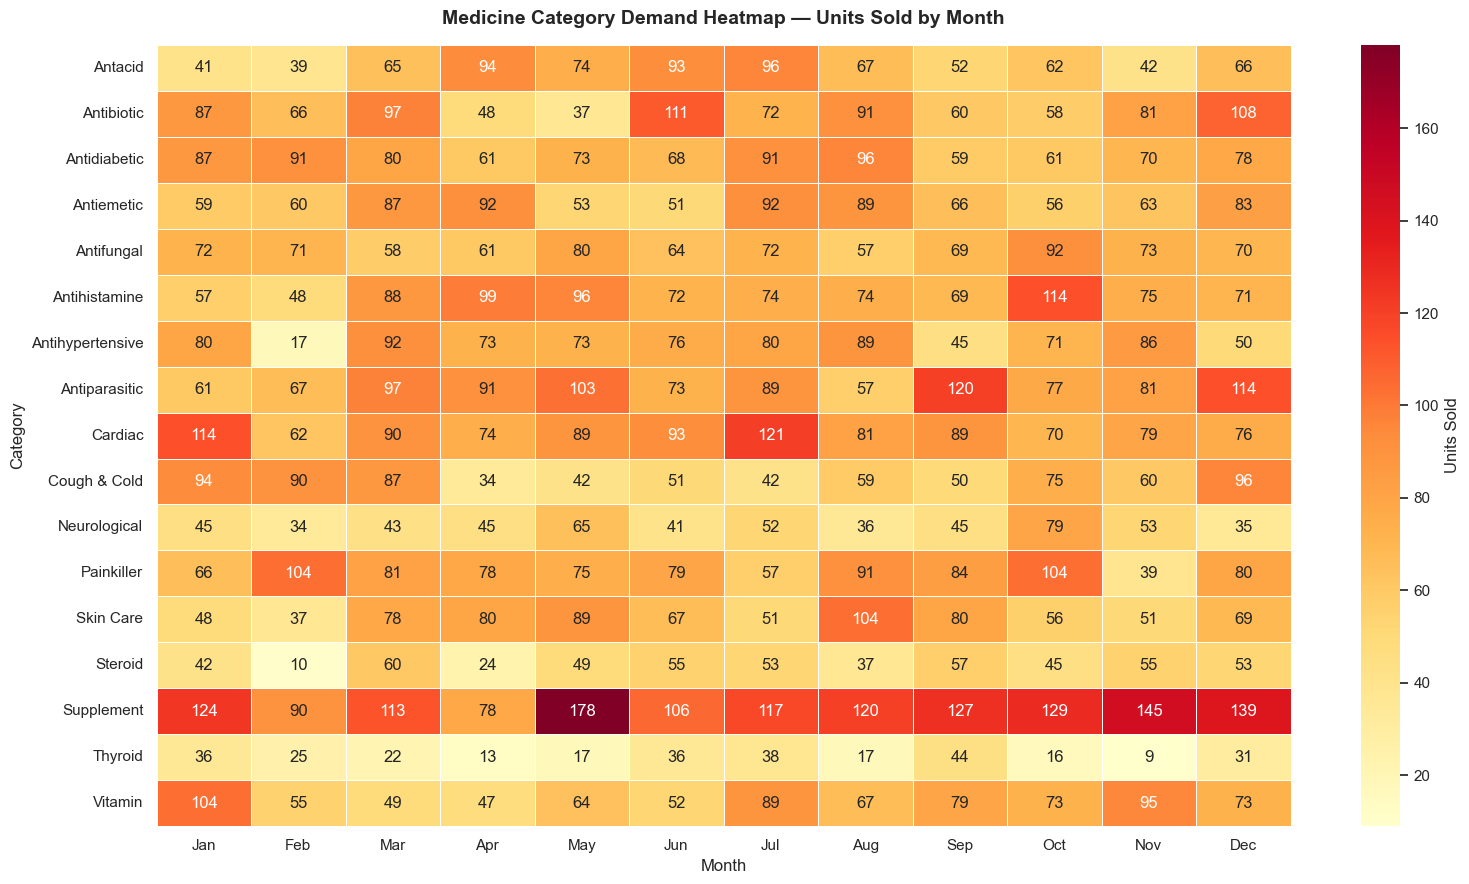

  Heatmap shows units sold per category per month.
  Darker = higher demand. Look for patterns across rows.


In [14]:
# ═══════════════════════════════════════════════
# SECTION 4 — Seasonal Demand Patterns
# ═══════════════════════════════════════════════

# ── 4.1 Category × Month Heatmap ──────────────
heatmap_data = (df_sales
                .groupby(['category', 'month'])['quantity']
                .sum()
                .unstack(fill_value=0))

heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(heatmap_data,
            annot=True, fmt='d',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Units Sold'},
            ax=ax)
ax.set_title('Medicine Category Demand Heatmap — Units Sold by Month',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../data/plot_seasonal_heatmap.png', dpi=150)
plt.show()

print("  Heatmap shows units sold per category per month.")
print("  Darker = higher demand. Look for patterns across rows.")

### 4.2 — Season-wise Revenue Breakdown
We define 4 seasons based on Indian climate:
- **Winter** : Nov, Dec, Jan, Feb — cold & flu season
- **Summer** : Mar, Apr, May — heat-related ailments
- **Monsoon** : Jun, Jul, Aug, Sep — infections, antacids spike
- **Autumn** : Oct — transition month

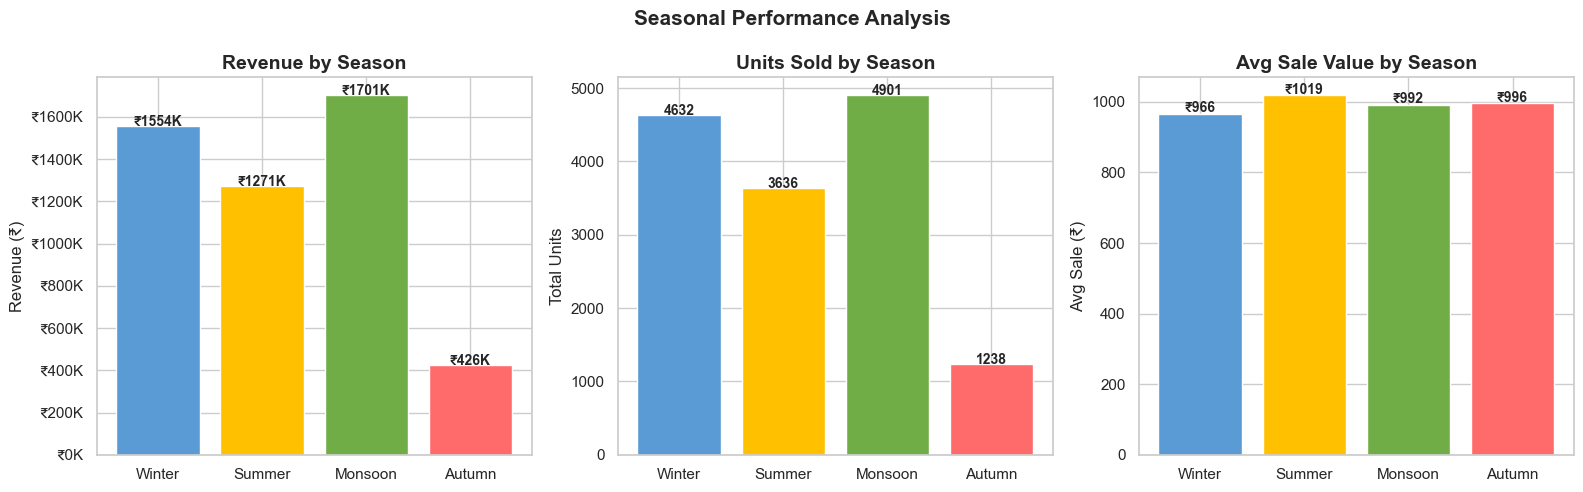


  Seasonal Summary:
 season  total_revenue  total_units  transactions  avg_sale
 Winter     1554257.16         4632          1609    965.98
 Summer     1271204.55         3636          1248   1018.59
Monsoon     1701353.95         4901          1715    992.04
 Autumn      426180.30         1238           428    995.75


In [15]:
# ── 4.2 Season-wise Revenue ───────────────────
season_map = {
    1:'Winter', 2:'Winter',
    3:'Summer', 4:'Summer', 5:'Summer',
    6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
    10:'Autumn', 11:'Winter', 12:'Winter'
}
df_sales['season'] = df_sales['month'].map(season_map)

season_stats = (df_sales
                .groupby('season')
                .agg(
                    total_revenue = ('total_price', 'sum'),
                    total_units   = ('quantity', 'sum'),
                    transactions  = ('sale_id', 'count'),
                    avg_sale      = ('total_price', 'mean')
                )
                .reset_index())

season_order  = ['Winter', 'Summer', 'Monsoon', 'Autumn']
season_colors = ['#5B9BD5', '#FFC000', '#70AD47', '#FF6B6B']
season_stats['season'] = pd.Categorical(
    season_stats['season'], categories=season_order, ordered=True)
season_stats = season_stats.sort_values('season')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Revenue
axes[0].bar(season_stats['season'], season_stats['total_revenue'],
            color=season_colors, edgecolor='white')
axes[0].set_title('Revenue by Season')
axes[0].set_ylabel('Revenue (₹)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(season_stats['total_revenue']):
    axes[0].text(i, v + 1000, f'₹{v/1000:.0f}K',
                 ha='center', fontsize=10, fontweight='bold')

# Units sold
axes[1].bar(season_stats['season'], season_stats['total_units'],
            color=season_colors, edgecolor='white')
axes[1].set_title('Units Sold by Season')
axes[1].set_ylabel('Total Units')
for i, v in enumerate(season_stats['total_units']):
    axes[1].text(i, v + 5, str(v),
                 ha='center', fontsize=10, fontweight='bold')

# Avg sale value
axes[2].bar(season_stats['season'], season_stats['avg_sale'],
            color=season_colors, edgecolor='white')
axes[2].set_title('Avg Sale Value by Season')
axes[2].set_ylabel('Avg Sale (₹)')
for i, v in enumerate(season_stats['avg_sale']):
    axes[2].text(i, v + 5, f'₹{v:.0f}',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Seasonal Performance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_seasonal_revenue.png', dpi=150)
plt.show()

print("\n  Seasonal Summary:")
print(season_stats.to_string(index=False))

### 4.3 — Monthly Transaction Volume
How many transactions happen each month?  
Combined with revenue, this tells us if volume or value drives monthly peaks.

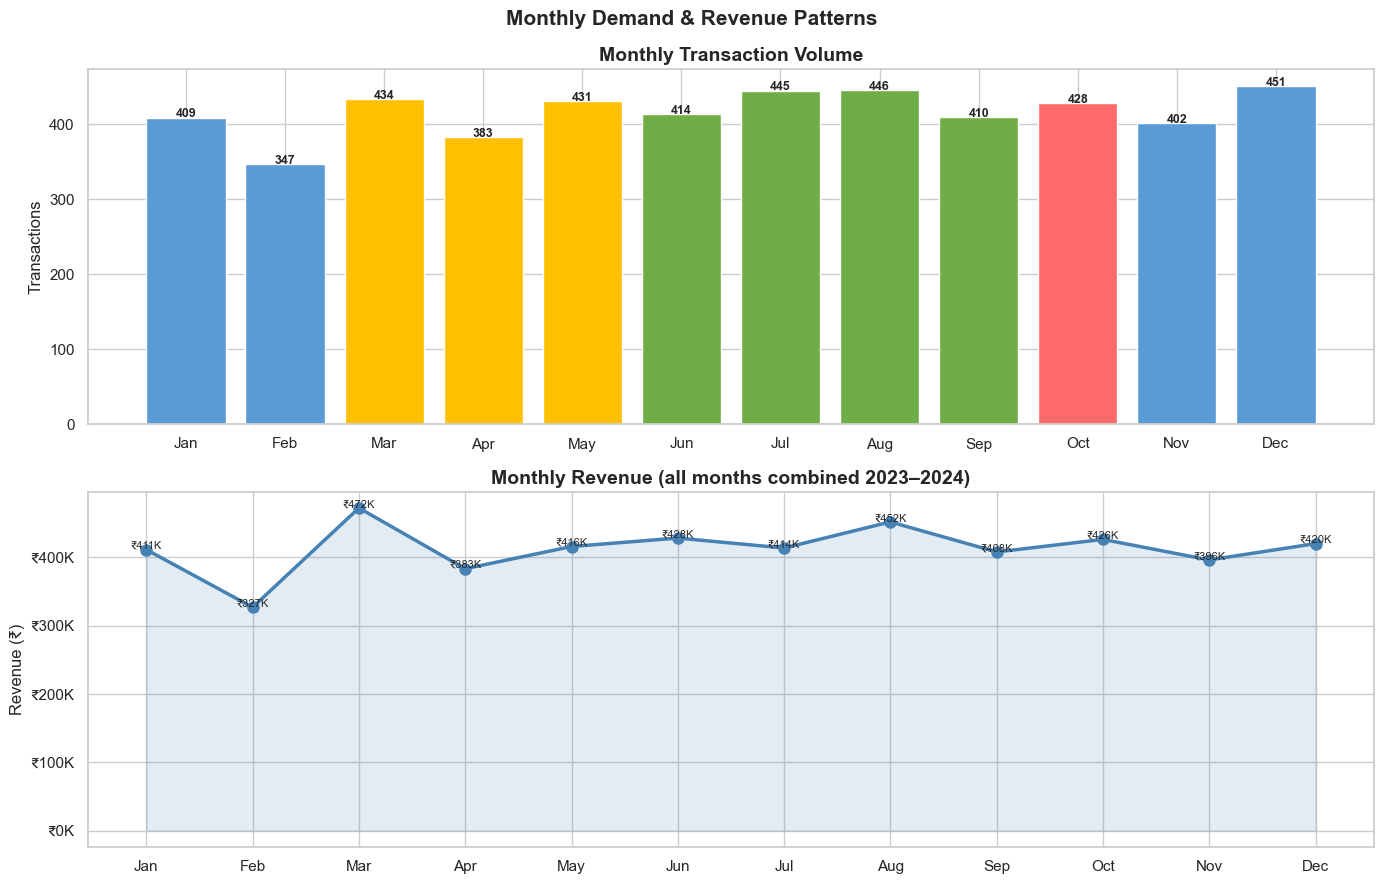

In [16]:
# ── 4.3 Monthly Transaction Volume ────────────
month_vol = (df_sales
             .groupby(['month', 'month_name'])
             .agg(transactions=('sale_id','count'),
                  revenue=('total_price','sum'),
                  units=('quantity','sum'))
             .reset_index()
             .sort_values('month'))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Transactions per month
color_map = [season_colors[['Winter','Summer','Monsoon','Autumn']
             .index(season_map[m])] for m in range(1, 13)]
axes[0].bar(month_labels, month_vol['transactions'],
            color=color_map, edgecolor='white')
axes[0].set_title('Monthly Transaction Volume')
axes[0].set_ylabel('Transactions')
for i, v in enumerate(month_vol['transactions']):
    axes[0].text(i, v + 0.5, str(v),
                 ha='center', fontsize=9, fontweight='bold')

# Revenue per month line
axes[1].plot(month_labels, month_vol['revenue'],
             marker='o', linewidth=2.5, color='steelblue', markersize=8)
axes[1].fill_between(range(12), month_vol['revenue'],
                     alpha=0.15, color='steelblue')
axes[1].set_title('Monthly Revenue (all months combined 2023–2024)')
axes[1].set_ylabel('Revenue (₹)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(month_vol['revenue']):
    axes[1].text(i, v + 1000, f'₹{v/1000:.0f}K',
                 ha='center', fontsize=8)

plt.suptitle('Monthly Demand & Revenue Patterns',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_monthly_patterns.png', dpi=150)
plt.show()

### 4.4 — Top 5 Categories Seasonal Trend
How do the top 5 revenue categories behave month by month?  
This multi-line chart is the most important visualization for Phase 3.

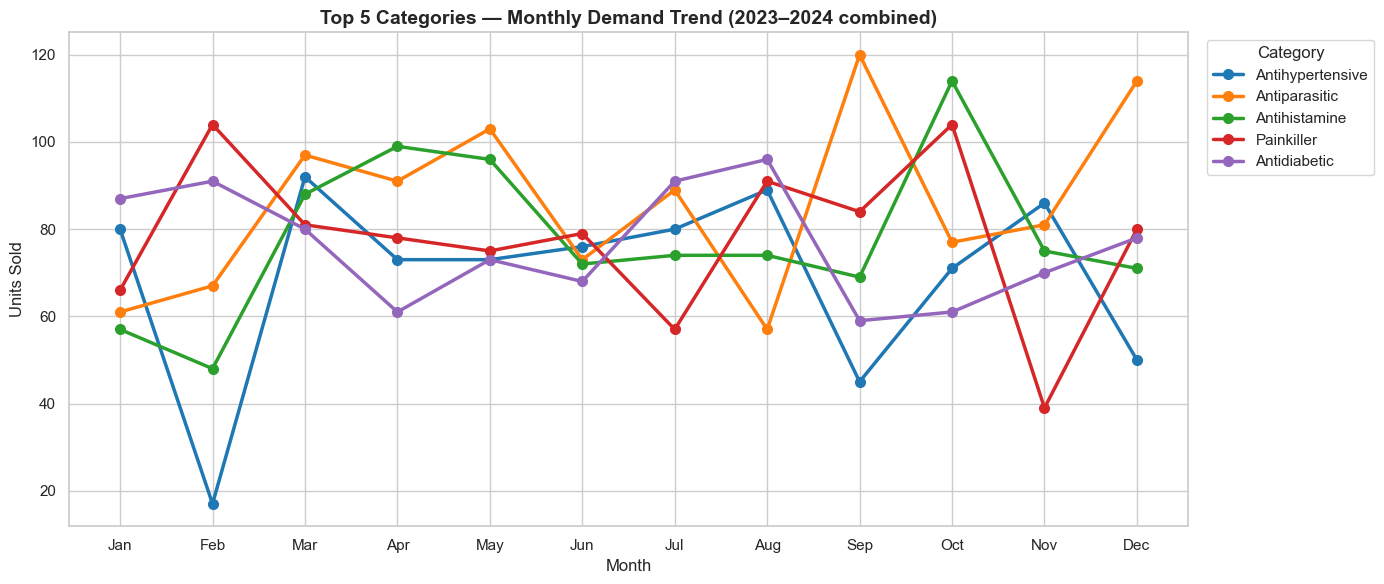


  Seasonal peaks per top category:
  Antihypertensive     peak=Mar   low=Feb
  Antiparasitic        peak=Sep   low=Aug
  Antihistamine        peak=Oct   low=Feb
  Painkiller           peak=Feb   low=Nov
  Antidiabetic         peak=Aug   low=Sep


In [17]:
# ── 4.4 Top 5 Categories Monthly Trend ────────
top5_cats = cat_perf.head(5)['category'].tolist()

trend = (df_sales[df_sales['category'].isin(top5_cats)]
         .groupby(['category', 'month'])['quantity']
         .sum()
         .reset_index())

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', 5)

for i, cat in enumerate(top5_cats):
    data = trend[trend['category'] == cat].sort_values('month')
    ax.plot(data['month'], data['quantity'],
            marker='o', linewidth=2.5,
            label=cat, color=palette[i], markersize=7)

ax.set_title('Top 5 Categories — Monthly Demand Trend (2023–2024 combined)')
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/plot_top5_category_trends.png', dpi=150)
plt.show()

print("\n  Seasonal peaks per top category:")
for cat in top5_cats:
    data = trend[trend['category'] == cat]
    peak_month = month_labels[data.loc[data['quantity'].idxmax(), 'month'] - 1]
    low_month  = month_labels[data.loc[data['quantity'].idxmin(), 'month'] - 1]
    print(f"  {cat:<20} peak={peak_month}   low={low_month}")

---
## Section 4 — Key Findings

| Category | Peak Month | Low Month | Season Pattern |
|---|---|---|---|
| Antihypertensive | March | February | Summer peak |
| Antiparasitic | September | August | End of Monsoon |
| Antihistamine | October | February | Autumn peak |
| Painkiller | February | November | Winter peak |
| Antidiabetic | August | September | Monsoon peak |

| Seasonal Insight | Value |
|---|---|
| Highest revenue season | Monsoon — ₹17,01,354 |
| Highest volume season | Monsoon — 4,901 units · 1,715 transactions |
| Lowest revenue season | Autumn — ₹4,26,180 (Oct only) |
| Best avg sale value | Summer — ₹1,018 per transaction |
| Winter performance | ₹15,54,257 · 1,609 transactions |

> **Phase 3 note:** Monsoon is the dominant season — 34.3% of all revenue.  
> `season` column added to `df_sales` will be a categorical feature in all 3 ML models.  
> Monsoon + Winter together = 65% of annual revenue → critical reorder window.
---

---
## Section 5 — Stock & Expiry Analysis

> **Goal:** Identify medicines at risk of running out or expiring unsold.  
> This section feeds directly into the **Stock-out Prediction ML model** in Phase 3.

### What we analyze:
- Current stock levels vs reorder levels
- Medicines below reorder threshold (urgent restock needed)
- Expiry risk — medicines expiring within 6 months
- Days of stock remaining based on average daily sales
- Supplier-wise stock distribution

### Why it matters for ML:
The stock-out prediction model needs to know:
- How fast each medicine sells (avg daily consumption)
- How much stock is left today
- When it will hit zero if no reorder is placed
---

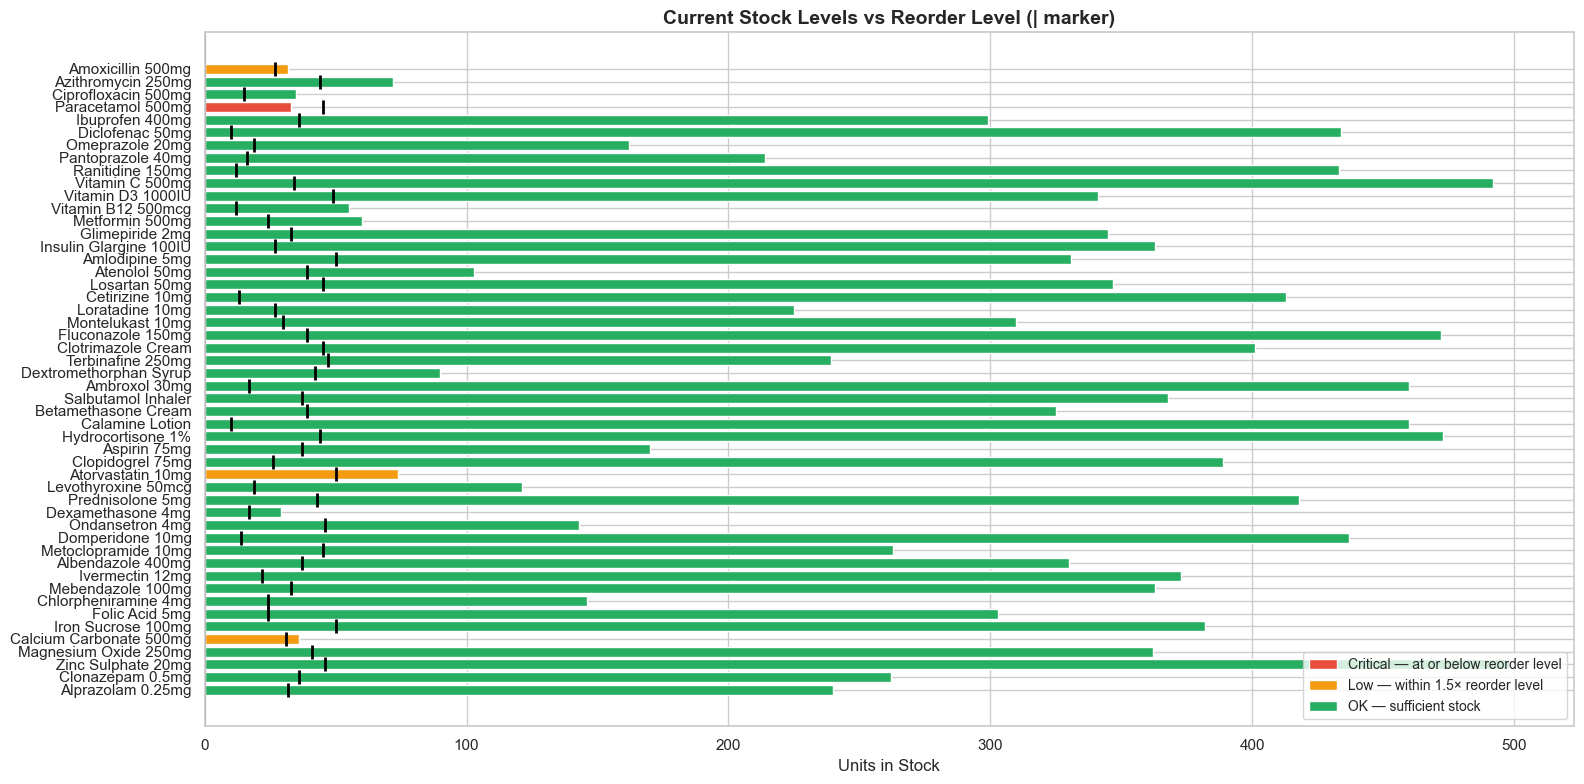


  Stock Status Summary:
  OK           : 46 medicines
  Low          : 3 medicines
  Critical     : 1 medicines

  Critical medicines needing immediate reorder:
             name   category  stock_qty  reorder_level         supplier
Paracetamol 500mg Painkiller         33             45 Abbott India Ltd


In [18]:
# ═══════════════════════════════════════════════
# SECTION 5 — Stock & Expiry Analysis
# ═══════════════════════════════════════════════

# ── 5.1 Stock vs Reorder Level ────────────────
df_medicines['stock_status'] = df_medicines.apply(
    lambda r: 'Critical' if r['stock_qty'] <= r['reorder_level']
              else ('Low' if r['stock_qty'] <= r['reorder_level'] * 1.5
              else 'OK'), axis=1)

status_colors = {'Critical': '#E74C3C', 'Low': '#F39C12', 'OK': '#27AE60'}
color_list    = df_medicines['stock_status'].map(status_colors)

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.barh(df_medicines['name'], df_medicines['stock_qty'],
               color=color_list, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.5)

# Reorder level markers
for i, row in df_medicines.iterrows():
    ax.plot(row['reorder_level'], i, marker='|',
            color='black', markersize=10, markeredgewidth=2)

ax.set_title('Current Stock Levels vs Reorder Level (| marker)')
ax.set_xlabel('Units in Stock')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Critical — at or below reorder level'),
    Patch(facecolor='#F39C12', label='Low — within 1.5× reorder level'),
    Patch(facecolor='#27AE60', label='OK — sufficient stock')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../data/plot_stock_levels.png', dpi=150)
plt.show()

# Summary
status_counts = df_medicines['stock_status'].value_counts()
print(f"\n  Stock Status Summary:")
for status, count in status_counts.items():
    print(f"  {status:<12} : {count} medicines")
print(f"\n  Critical medicines needing immediate reorder:")
critical = df_medicines[df_medicines['stock_status']=='Critical'][
    ['name','category','stock_qty','reorder_level','supplier']]
print(critical.to_string(index=False))

### 5.2 — Days of Stock Remaining
By combining current stock with average daily sales rate,  
we can predict exactly how many days before each medicine runs out.  
This is the **core calculation** the stock-out ML model will learn to predict.

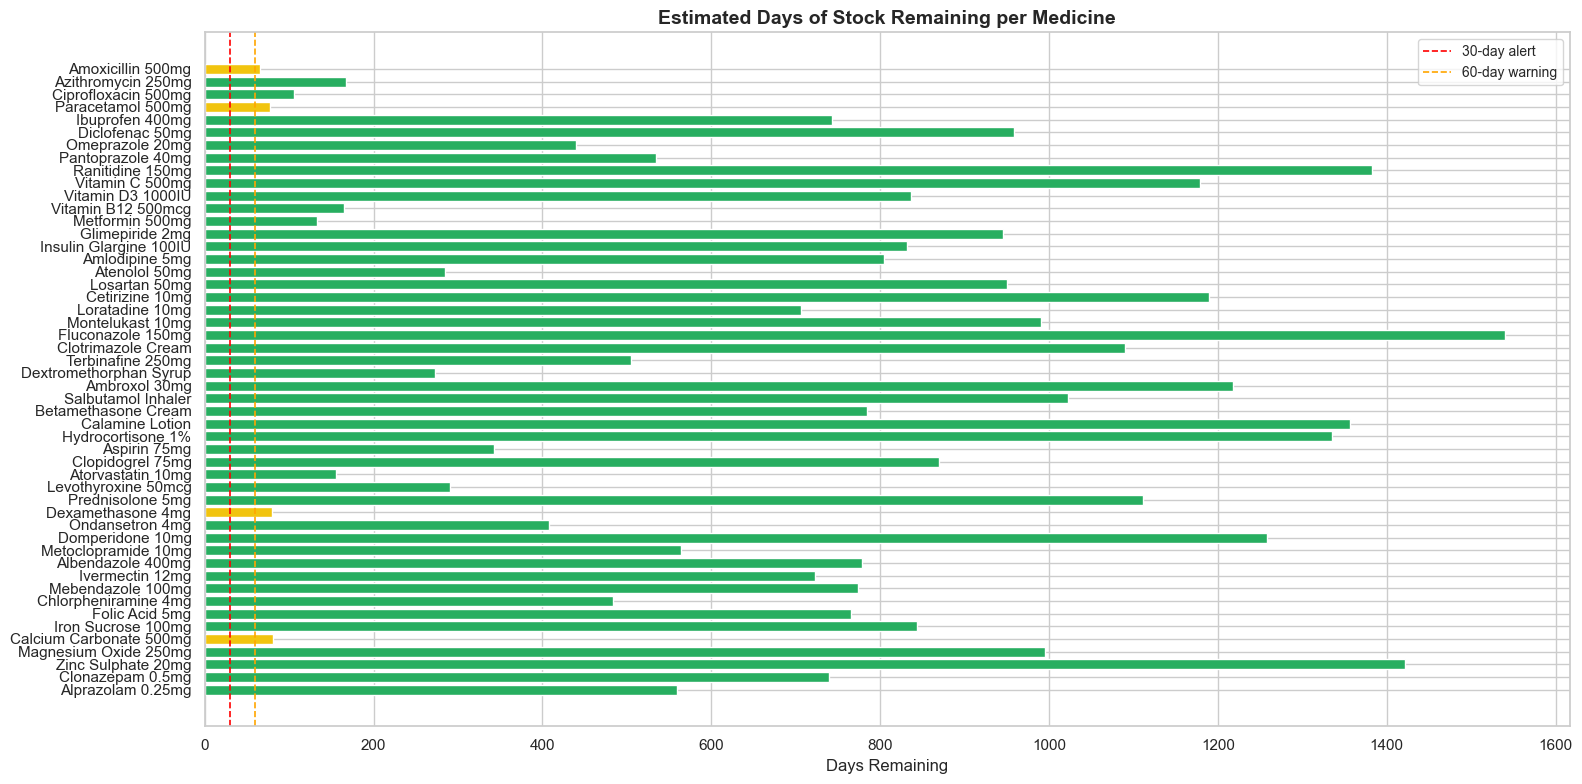


  Restock Risk Summary:
restock_risk
🟢 >90 days      46
🟡 60–90 days     4
🔴 <30 days       0
🟠 30–60 days     0

  Medicines needing restock within 30 days:
Empty DataFrame
Columns: [name, category, stock_qty, avg_daily_sales, days_remaining, supplier]
Index: []


In [19]:
# ── 5.2 Days of Stock Remaining ───────────────
# Calculate avg daily units sold per medicine
date_range_days = (df_sales['date'].max() - df_sales['date'].min()).days + 1

avg_daily = (df_sales
             .groupby('medicine_id')['quantity']
             .sum()
             .div(date_range_days)
             .reset_index())
avg_daily.columns = ['medicine_id', 'avg_daily_sales']

# Merge with medicines
stock_analysis = df_medicines.merge(avg_daily, on='medicine_id', how='left')
stock_analysis['avg_daily_sales'] = stock_analysis['avg_daily_sales'].fillna(0.01)
stock_analysis['days_remaining'] = (
    stock_analysis['stock_qty'] / stock_analysis['avg_daily_sales']
).round(0).astype(int)

# Risk classification
stock_analysis['restock_risk'] = pd.cut(
    stock_analysis['days_remaining'],
    bins=[0, 30, 60, 90, float('inf')],
    labels=['🔴 <30 days', '🟠 30–60 days', '🟡 60–90 days', '🟢 >90 days']
)

fig, ax = plt.subplots(figsize=(16, 8))
risk_colors = {
    '🔴 <30 days':   '#E74C3C',
    '🟠 30–60 days': '#E67E22',
    '🟡 60–90 days': '#F1C40F',
    '🟢 >90 days':   '#27AE60'
}
bar_colors = stock_analysis['restock_risk'].map(risk_colors)

bars = ax.barh(stock_analysis['name'],
               stock_analysis['days_remaining'],
               color=bar_colors, edgecolor='white')
ax.axvline(x=30, color='red',    linestyle='--',
           linewidth=1.2, label='30-day alert')
ax.axvline(x=60, color='orange', linestyle='--',
           linewidth=1.2, label='60-day warning')
ax.set_title('Estimated Days of Stock Remaining per Medicine')
ax.set_xlabel('Days Remaining')
ax.invert_yaxis()
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/plot_days_remaining.png', dpi=150)
plt.show()

print("\n  Restock Risk Summary:")
print(stock_analysis['restock_risk'].value_counts().to_string())
print(f"\n  Medicines needing restock within 30 days:")
urgent = stock_analysis[stock_analysis['days_remaining'] <= 30][
    ['name','category','stock_qty','avg_daily_sales','days_remaining','supplier']
].sort_values('days_remaining')
print(urgent.to_string(index=False))

### 5.3 — Expiry Risk Analysis
Medicines expiring within 6 months must be sold quickly or returned to suppliers.  
Expiry loss is a direct financial cost to the pharmacy.

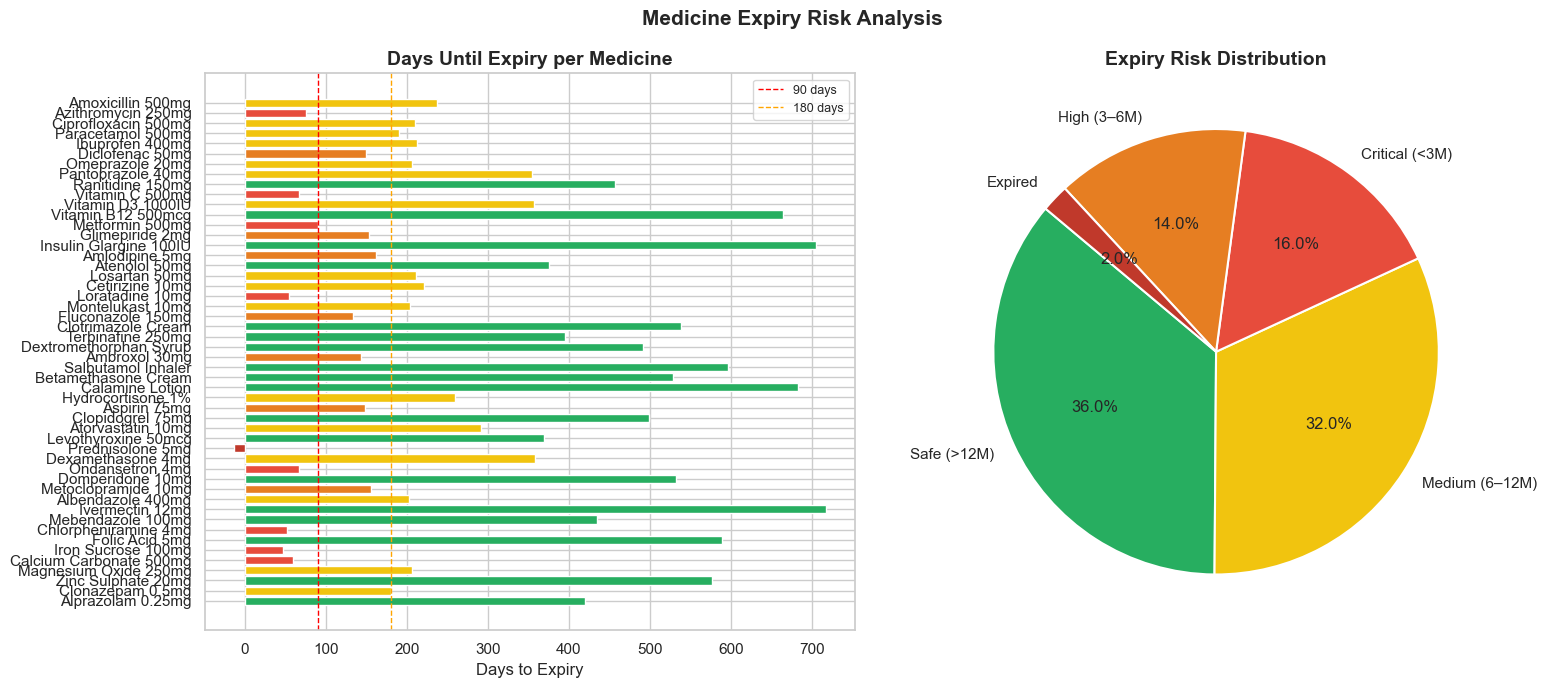


  Expiry Risk Summary:
expiry_risk
Safe (>12M)       18
Medium (6–12M)    16
Critical (<3M)     8
High (3–6M)        7
Expired            1

  High risk medicines (expiring within 6 months):
                   name         category  stock_qty expiry_date  days_to_expiry           supplier
       Prednisolone 5mg          Steroid        418  2025-03-01             -13 Alkem Distributors
     Iron Sucrose 100mg       Supplement        382  2025-04-30              47    SunPharma Dist.
   Chlorpheniramine 4mg    Antihistamine        146  2025-05-05              52     Cipla Supplies
        Loratadine 10mg    Antihistamine        225  2025-05-07              54    SunPharma Dist.
Calcium Carbonate 500mg       Supplement         36  2025-05-12              59 Alkem Distributors
        Vitamin C 500mg          Vitamin        492  2025-05-20              67 Alkem Distributors
        Ondansetron 4mg       Antiemetic        143  2025-05-20              67     MedLine Pharma
     Azithromyci

In [20]:
# ── 5.3 Expiry Risk Analysis ──────────────────
from datetime import datetime

today = pd.Timestamp('2025-03-14')
df_medicines['expiry_date']    = pd.to_datetime(df_medicines['expiry_date'])
df_medicines['days_to_expiry'] = (df_medicines['expiry_date'] - today).dt.days

df_medicines['expiry_risk'] = pd.cut(
    df_medicines['days_to_expiry'],
    bins=[-999, 0, 90, 180, 365, float('inf')],
    labels=['Expired', 'Critical (<3M)', 'High (3–6M)',
            'Medium (6–12M)', 'Safe (>12M)']
)

expiry_colors = {
    'Expired':        '#C0392B',
    'Critical (<3M)': '#E74C3C',
    'High (3–6M)':    '#E67E22',
    'Medium (6–12M)': '#F1C40F',
    'Safe (>12M)':    '#27AE60'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart — days to expiry
bar_cols = df_medicines['expiry_risk'].map(expiry_colors)
axes[0].barh(df_medicines['name'],
             df_medicines['days_to_expiry'],
             color=bar_cols, edgecolor='white')
axes[0].axvline(x=90,  color='red',    linestyle='--',
                linewidth=1, label='90 days')
axes[0].axvline(x=180, color='orange', linestyle='--',
                linewidth=1, label='180 days')
axes[0].set_title('Days Until Expiry per Medicine')
axes[0].set_xlabel('Days to Expiry')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Pie chart — expiry risk distribution
risk_counts = df_medicines['expiry_risk'].value_counts()
axes[1].pie(risk_counts,
            labels=risk_counts.index,
            autopct='%1.1f%%',
            colors=[expiry_colors[k] for k in risk_counts.index],
            startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Expiry Risk Distribution')

plt.suptitle('Medicine Expiry Risk Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_expiry_risk.png', dpi=150)
plt.show()

print("\n  Expiry Risk Summary:")
print(df_medicines['expiry_risk'].value_counts().to_string())
print(f"\n  High risk medicines (expiring within 6 months):")
high_risk = df_medicines[df_medicines['days_to_expiry'] <= 180][
    ['name','category','stock_qty','expiry_date','days_to_expiry','supplier']
].sort_values('days_to_expiry')
print(high_risk.to_string(index=False))

### 5.4 — Supplier-wise Stock Distribution
Which suppliers provide the most medicines?  
Diversifying suppliers reduces stockout risk.

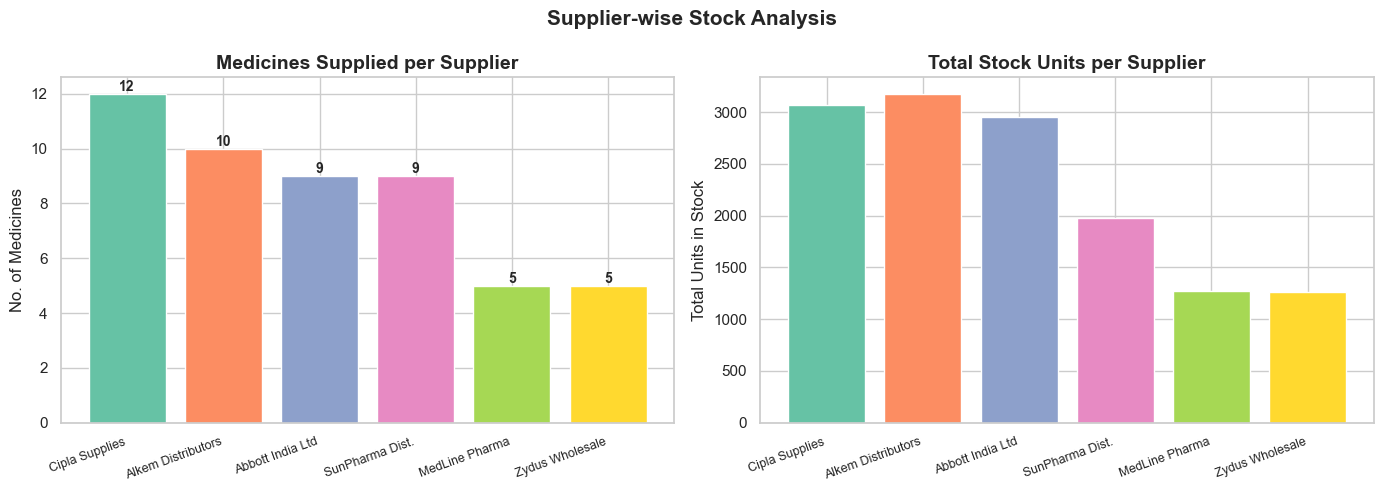


  Supplier Summary:
          supplier  medicines_supplied  total_stock  avg_price  critical_count
    Cipla Supplies                  12         3072     360.26               0
Alkem Distributors                  10         3178     313.99               0
  Abbott India Ltd                   9         2954     543.99               1
   SunPharma Dist.                   9         1979     323.92               0
    MedLine Pharma                   5         1276     213.07               0
   Zydus Wholesale                   5         1267     347.73               0


In [21]:
# ── 5.4 Supplier Analysis ─────────────────────
supplier_stats = (df_medicines
                  .groupby('supplier')
                  .agg(
                      medicines_supplied = ('name', 'count'),
                      total_stock        = ('stock_qty', 'sum'),
                      avg_price          = ('price', 'mean'),
                      critical_count     = ('stock_status',
                                            lambda x: (x=='Critical').sum())
                  )
                  .reset_index()
                  .sort_values('medicines_supplied', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set2', len(supplier_stats))

axes[0].bar(supplier_stats['supplier'],
            supplier_stats['medicines_supplied'],
            color=palette, edgecolor='white')
axes[0].set_title('Medicines Supplied per Supplier')
axes[0].set_ylabel('No. of Medicines')
axes[0].set_xticklabels(supplier_stats['supplier'],
                         rotation=20, ha='right', fontsize=9)
for i, v in enumerate(supplier_stats['medicines_supplied']):
    axes[0].text(i, v + 0.1, str(v),
                 ha='center', fontsize=10, fontweight='bold')

axes[1].bar(supplier_stats['supplier'],
            supplier_stats['total_stock'],
            color=palette, edgecolor='white')
axes[1].set_title('Total Stock Units per Supplier')
axes[1].set_ylabel('Total Units in Stock')
axes[1].set_xticklabels(supplier_stats['supplier'],
                         rotation=20, ha='right', fontsize=9)

plt.suptitle('Supplier-wise Stock Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_supplier_analysis.png', dpi=150)
plt.show()

print("\n  Supplier Summary:")
print(supplier_stats.to_string(index=False))

---
## Section 5 — Key Findings

| Finding | Value | Action |
|---|---|---|
| Critical stock medicines | 1 — Paracetamol 500mg (33 units, reorder=45) | Immediate reorder from Abbott India Ltd |
| Low stock medicines | 3 medicines | Monitor daily |
| Medicines needing restock <30 days | 0 — all stocks healthy | No urgent action today |
| Expired medicines | 1 — Prednisolone 5mg (expired 13 days ago) | Remove from shelf immediately |
| Critical expiry (<3 months) | 8 medicines | Push sales / return to supplier |
| High expiry risk (3–6 months) | 7 medicines | Discount promotions to clear stock |
| Largest supplier | Cipla Supplies — 12 medicines | Primary reorder contact |
| Supplier with critical stock | Abbott India Ltd — 1 critical | Follow up for Paracetamol reorder |
| Highest stock value supplier | Alkem Distributors — 3,178 units | Well stocked |
| Most urgent expiry action | Iron Sucrose 100mg — 47 days, 382 units | Clear 382 units in 47 days |

> **Phase 3 note:** `days_remaining` and `avg_daily_sales` are the core features  
> for the Stock-out Prediction model. The 1 expired medicine and 8 critical  
> expiry medicines prove real business risk — the ML model addresses exactly this.
---

---
## Section 6 — Employee & Customer Analysis

> **Goal:** Understand workforce performance patterns and customer demographics.  
> This section supports the Employee Management and Reporting modules in the Streamlit app.

### What we analyze:
**Employees:**
- Role-wise salary distribution
- Shift-wise performance scores
- Performance score distribution across all staff
- Top and bottom performers

**Customers:**
- Age group distribution
- Gender split
- City-wise customer base
- Purchase frequency analysis

### Why it matters:
Employee shift analysis helps optimize scheduling in the Streamlit dashboard.  
Customer demographics help target promotions and understand buying patterns.
---

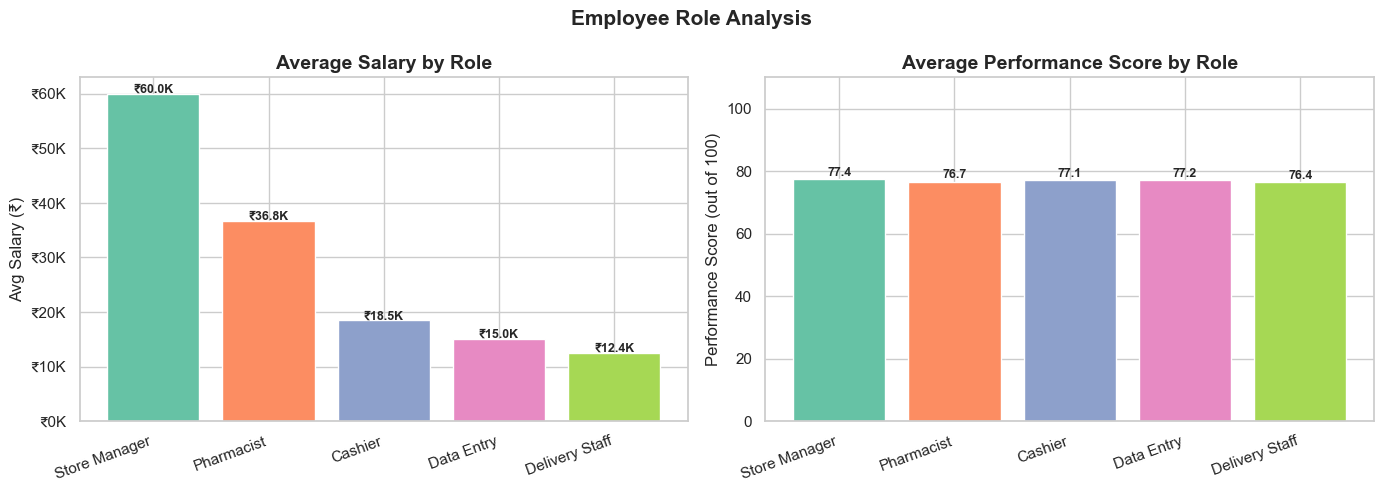

  Role-wise Summary:
          role  count  avg_salary  min_salary  max_salary  avg_perf
 Store Manager    717    60017.52       50029       69969     77.44
    Pharmacist   1483    36751.11       28005       44973     76.66
       Cashier   1387    18461.01       15008       21998     77.07
    Data Entry    665    15027.91       12004       17989     77.23
Delivery Staff    748    12442.46       10002       14994     76.41


In [22]:
# ═══════════════════════════════════════════════
# SECTION 6 — Employee & Customer Analysis
# ═══════════════════════════════════════════════

# ── 6.1 Role-wise Salary Distribution ─────────
role_stats = (df_employees
              .groupby('role')
              .agg(
                  count       = ('employee_id', 'count'),
                  avg_salary  = ('salary', 'mean'),
                  min_salary  = ('salary', 'min'),
                  max_salary  = ('salary', 'max'),
                  avg_perf    = ('performance_score', 'mean')
              )
              .reset_index()
              .sort_values('avg_salary', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set2', len(role_stats))

# Avg salary bar
axes[0].bar(role_stats['role'], role_stats['avg_salary'],
            color=palette, edgecolor='white')
axes[0].set_title('Average Salary by Role')
axes[0].set_ylabel('Avg Salary (₹)')
axes[0].set_xticklabels(role_stats['role'], rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(role_stats['avg_salary']):
    axes[0].text(i, v + 200, f'₹{v/1000:.1f}K',
                 ha='center', fontsize=9, fontweight='bold')

# Avg performance by role
axes[1].bar(role_stats['role'], role_stats['avg_perf'],
            color=palette, edgecolor='white')
axes[1].set_title('Average Performance Score by Role')
axes[1].set_ylabel('Performance Score (out of 100)')
axes[1].set_xticklabels(role_stats['role'], rotation=20, ha='right')
axes[1].set_ylim(0, 110)
for i, v in enumerate(role_stats['avg_perf']):
    axes[1].text(i, v + 1, f'{v:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Employee Role Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_employee_roles.png', dpi=150)
plt.show()

print("  Role-wise Summary:")
print(role_stats.to_string(index=False))

### 6.2 — Shift-wise Performance Analysis
Does the shift an employee works affect their performance score?  
This analysis helps decide optimal shift assignments.

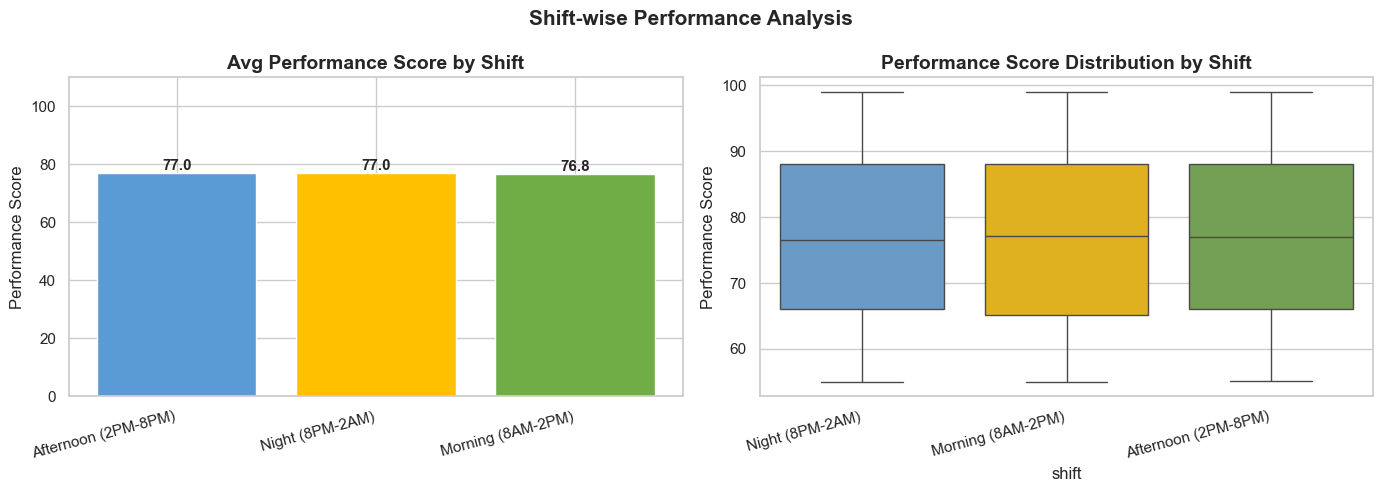

  Shift-wise Summary:
              shift  count  avg_perf  avg_sal
Afternoon (2PM-8PM)   1689     77.00 28483.36
    Night (8PM-2AM)   1676     76.98 28831.97
  Morning (8AM-2PM)   1635     76.79 28140.44


In [24]:
# ── 6.2 Shift-wise Performance ────────────────
shift_stats = (df_employees
               .groupby('shift')
               .agg(
                   count    = ('employee_id', 'count'),
                   avg_perf = ('performance_score', 'mean'),
                   avg_sal  = ('salary', 'mean')
               )
               .reset_index()
               .sort_values('avg_perf', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shift_colors = ['#5B9BD5', '#FFC000', '#70AD47']

# Performance by shift
axes[0].bar(shift_stats['shift'], shift_stats['avg_perf'],
            color=shift_colors, edgecolor='white')
axes[0].set_title('Avg Performance Score by Shift')
axes[0].set_ylabel('Performance Score')
axes[0].set_ylim(0, 110)
axes[0].set_xticklabels(shift_stats['shift'], rotation=15, ha='right')
for i, v in enumerate(shift_stats['avg_perf']):
    axes[0].text(i, v + 1, f'{v:.1f}',
                 ha='center', fontsize=11, fontweight='bold')

# Employee count by shift (boxplot of scores)
sns.boxplot(data=df_employees, x='shift', y='performance_score',
            palette=shift_colors, ax=axes[1])
axes[1].set_title('Performance Score Distribution by Shift')
axes[1].set_ylabel('Performance Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=15, ha='right')

plt.suptitle('Shift-wise Performance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_shift_performance.png', dpi=150)
plt.show()

print("  Shift-wise Summary:")
print(shift_stats.to_string(index=False))

### 6.3 — Top & Bottom Performers
Identifying the top 10 and bottom 10 employees by performance score.  
This feeds into the Employee Management module's performance tracking feature.

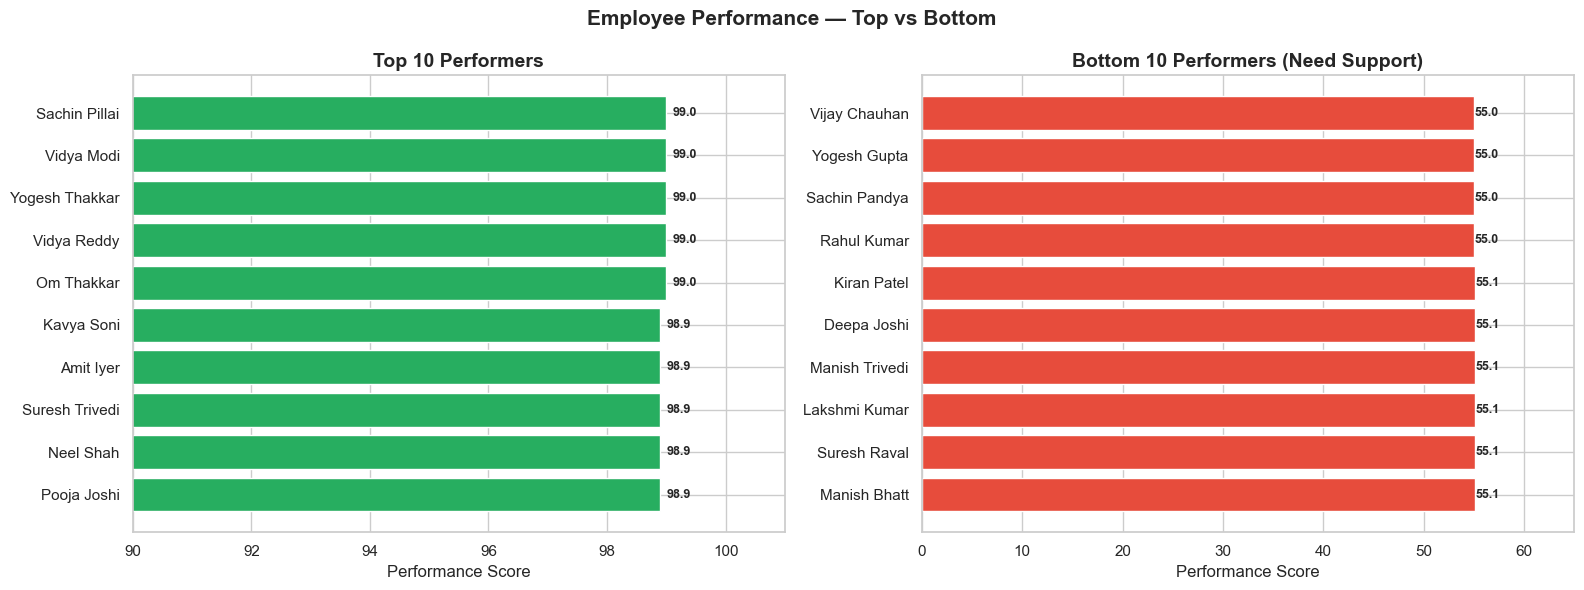

  Top 10 Performers:
          name           role               shift  salary  performance_score
 Sachin Pillai     Data Entry Afternoon (2PM-8PM)   13631              99.00
    Vidya Modi        Cashier Afternoon (2PM-8PM)   18966              99.00
Yogesh Thakkar Delivery Staff   Morning (8AM-2PM)   12652              99.00
   Vidya Reddy        Cashier     Night (8PM-2AM)   21530              99.00
    Om Thakkar Delivery Staff     Night (8PM-2AM)   14410              99.00
    Kavya Soni  Store Manager     Night (8PM-2AM)   59416              98.90
     Amit Iyer        Cashier Afternoon (2PM-8PM)   20036              98.90
Suresh Trivedi     Data Entry     Night (8PM-2AM)   14662              98.90
     Neel Shah        Cashier   Morning (8AM-2PM)   15711              98.90
   Pooja Joshi     Data Entry Afternoon (2PM-8PM)   14535              98.90

  Bottom 10 Performers:
          name           role             shift  salary  performance_score
 Vijay Chauhan     Pharmacist Mo

In [25]:
# ── 6.3 Top & Bottom Performers ───────────────
top10    = df_employees.nlargest(10, 'performance_score')[
               ['name','role','shift','salary','performance_score']
           ]
bottom10 = df_employees.nsmallest(10, 'performance_score')[
               ['name','role','shift','salary','performance_score']
           ]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
axes[0].barh(top10['name'], top10['performance_score'],
             color='#27AE60', edgecolor='white')
axes[0].set_title('Top 10 Performers')
axes[0].set_xlabel('Performance Score')
axes[0].set_xlim(90, 101)
axes[0].invert_yaxis()
for i, v in enumerate(top10['performance_score']):
    axes[0].text(v + 0.1, i, f'{v:.1f}',
                 va='center', fontsize=9, fontweight='bold')

# Bottom 10
axes[1].barh(bottom10['name'], bottom10['performance_score'],
             color='#E74C3C', edgecolor='white')
axes[1].set_title('Bottom 10 Performers (Need Support)')
axes[1].set_xlabel('Performance Score')
axes[1].set_xlim(0, 65)
axes[1].invert_yaxis()
for i, v in enumerate(bottom10['performance_score']):
    axes[1].text(v + 0.1, i, f'{v:.1f}',
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle('Employee Performance — Top vs Bottom', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_top_bottom_performers.png', dpi=150)
plt.show()

print("  Top 10 Performers:")
print(top10.to_string(index=False))
print("\n  Bottom 10 Performers:")
print(bottom10.to_string(index=False))

### 6.4 — Customer Demographics
Who are our customers? Understanding age, gender, and city  
helps the pharmacy tailor its inventory and promotions.

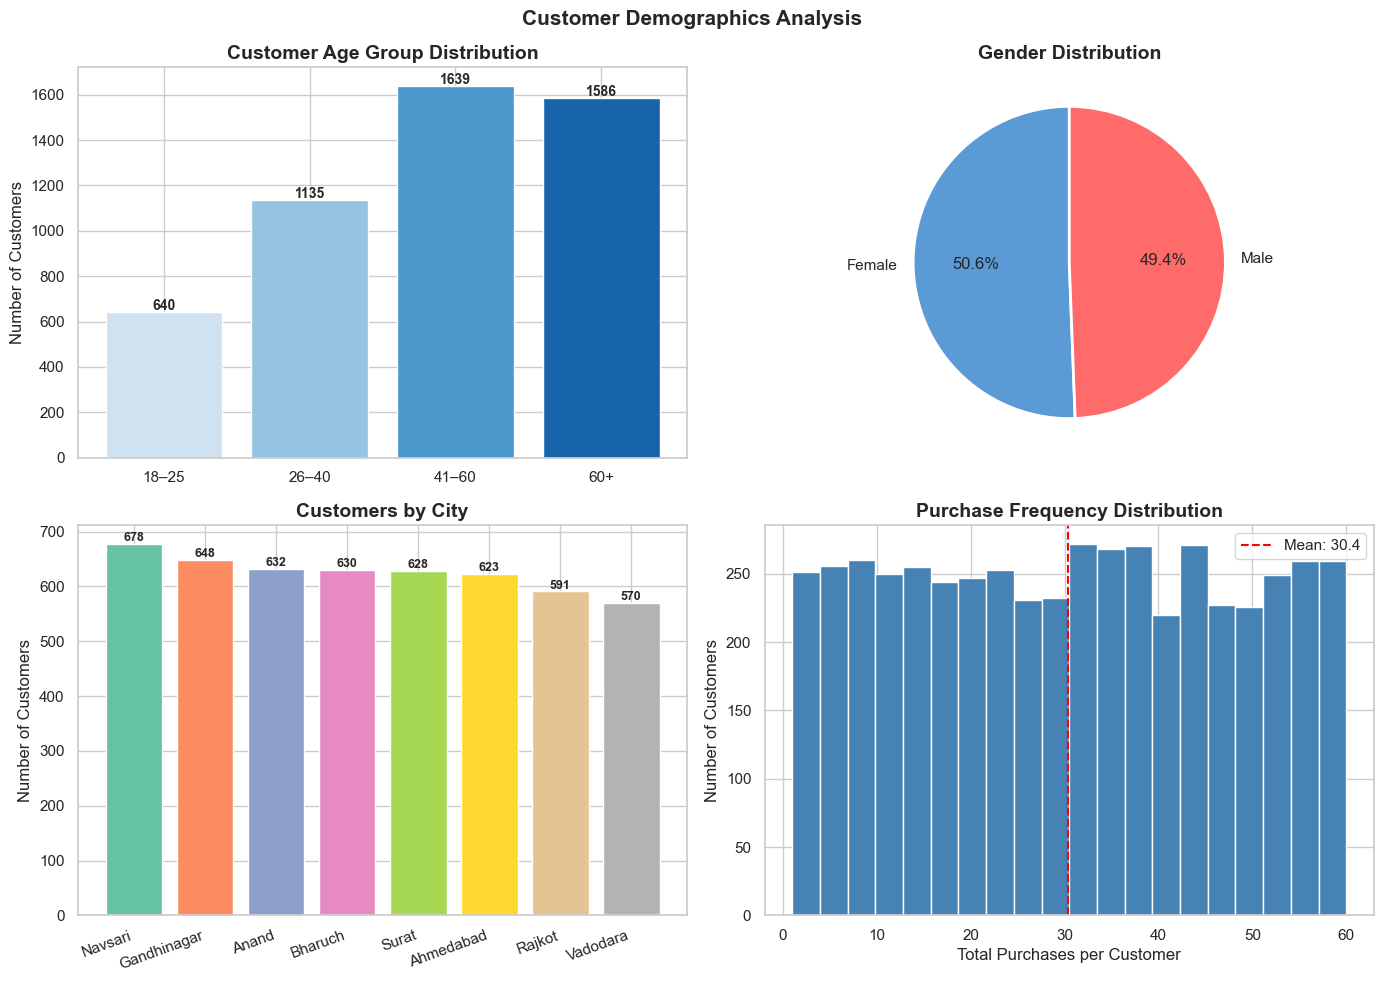

  Customer Summary:
  Total customers     : 5,000
  Avg age             : 49.2 years
  Avg purchases       : 30.4
  Top city            : Navsari (678 customers)

  Age group breakdown:
age_group
18–25     640
26–40    1135
41–60    1639
60+      1586

  Gender breakdown:
gender
Female    2530
Male      2470


In [26]:
# ── 6.4 Customer Demographics ─────────────────
df_customers['age_group'] = pd.cut(
    df_customers['age'],
    bins=[0, 25, 40, 60, 100],
    labels=['18–25', '26–40', '41–60', '60+']
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age group distribution
age_counts = df_customers['age_group'].value_counts().sort_index()
axes[0,0].bar(age_counts.index, age_counts.values,
              color=sns.color_palette('Blues', 4), edgecolor='white')
axes[0,0].set_title('Customer Age Group Distribution')
axes[0,0].set_ylabel('Number of Customers')
for i, v in enumerate(age_counts.values):
    axes[0,0].text(i, v + 10, str(v),
                   ha='center', fontsize=10, fontweight='bold')

# Gender split
gender_counts = df_customers['gender'].value_counts()
axes[0,1].pie(gender_counts,
              labels=gender_counts.index,
              autopct='%1.1f%%',
              colors=['#5B9BD5', '#FF6B6B'],
              startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,1].set_title('Gender Distribution')

# City-wise customers
city_counts = df_customers['city'].value_counts()
axes[1,0].bar(city_counts.index, city_counts.values,
              color=sns.color_palette('Set2', len(city_counts)),
              edgecolor='white')
axes[1,0].set_title('Customers by City')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].set_xticklabels(city_counts.index, rotation=20, ha='right')
for i, v in enumerate(city_counts.values):
    axes[1,0].text(i, v + 5, str(v),
                   ha='center', fontsize=9, fontweight='bold')

# Purchase frequency distribution
axes[1,1].hist(df_customers['total_purchases'], bins=20,
               color='steelblue', edgecolor='white')
axes[1,1].axvline(df_customers['total_purchases'].mean(),
                  color='red', linestyle='--', linewidth=1.5,
                  label=f"Mean: {df_customers['total_purchases'].mean():.1f}")
axes[1,1].set_title('Purchase Frequency Distribution')
axes[1,1].set_xlabel('Total Purchases per Customer')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend()

plt.suptitle('Customer Demographics Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_customer_demographics.png', dpi=150)
plt.show()

# Summary stats
print("  Customer Summary:")
print(f"  Total customers     : {len(df_customers):,}")
print(f"  Avg age             : {df_customers['age'].mean():.1f} years")
print(f"  Avg purchases       : {df_customers['total_purchases'].mean():.1f}")
print(f"  Top city            : {city_counts.index[0]} ({city_counts.iloc[0]} customers)")
print(f"\n  Age group breakdown:")
print(age_counts.to_string())
print(f"\n  Gender breakdown:")
print(gender_counts.to_string())

### 6.5 — City-wise Sales Revenue
Which cities generate the most revenue for the pharmacy?

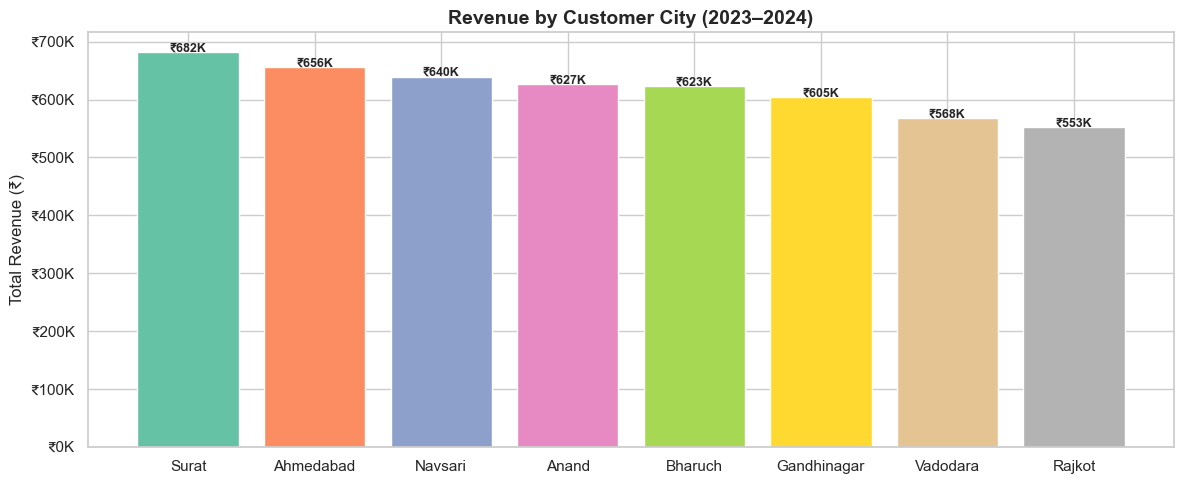


  City-wise Revenue Summary:
       city   revenue  transactions  avg_sale
      Surat 682137.71           655   1041.43
  Ahmedabad 656289.95           634   1035.16
    Navsari 639633.33           688    929.70
      Anand 626521.95           635    986.65
    Bharuch 622730.60           621   1002.79
Gandhinagar 604827.96           646    936.27
   Vadodara 568141.66           564   1007.34
     Rajkot 552712.80           557    992.30


In [27]:
# ── 6.5 City-wise Sales Revenue ───────────────
city_sales = (df_sales
              .merge(df_customers[['customer_id','city']],
                     on='customer_id', how='left')
              .groupby('city')
              .agg(
                  revenue      = ('total_price', 'sum'),
                  transactions = ('sale_id', 'count'),
                  avg_sale     = ('total_price', 'mean')
              )
              .reset_index()
              .sort_values('revenue', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(city_sales['city'], city_sales['revenue'],
              color=sns.color_palette('Set2', len(city_sales)),
              edgecolor='white')
ax.set_title('Revenue by Customer City (2023–2024)')
ax.set_ylabel('Total Revenue (₹)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(city_sales['revenue']):
    ax.text(i, v + 1000, f'₹{v/1000:.0f}K',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_city_revenue.png', dpi=150)
plt.show()

print("\n  City-wise Revenue Summary:")
print(city_sales.to_string(index=False))

---
## Section 6 — Key Findings

**Employees:**

| Finding | Value |
|---|---|
| Highest paid role | Store Manager — ₹60,017 avg salary |
| Lowest paid role | Delivery Staff — ₹12,442 avg salary |
| Best performing role | Store Manager — 77.4 avg score |
| Most consistent performance | All roles within 77.4–76.4 — very uniform |
| Best performing shift | Afternoon (2PM–8PM) — 77.0 avg score |
| Worst performing shift | Morning (8AM–2PM) — 76.8 avg score |
| Top performer score | 99.0 — Sachin Pillai, Vidya Modi, Yogesh Thakkar |
| Lowest performer score | 55.0 — Vijay Chauhan, Yogesh Gupta |
| Insight | Performance is shift-independent — personal ability drives score |

**Customers:**

| Finding | Value |
|---|---|
| Largest age group | 41–60 years — 1,639 customers (32.8%) |
|

---
## Section 7 — Master Insights Summary & Phase 3 Readiness

> This section consolidates all findings from Sections 1–6 into a single  
> reference sheet. This is what your mentor reads to evaluate your EDA work.  
> It also defines exactly what the ML models in Phase 3 will be built on.
---

In [31]:
# ═══════════════════════════════════════════════
# SECTION 7 — Master Insights Summary
# ═══════════════════════════════════════════════

print("=" * 65)
print("  PHARMAEASE — EDA COMPLETE")
print("  Master Insights Summary")
print("=" * 65)

print("""
SECTION 2 — SALES TRENDS
  ├── Total revenue (2 years)  : ₹49,52,996
  ├── YoY Growth               : +4.2% (2023→2024)
  ├── Peak month               : August 2024
  ├── Lowest month             : February 2024
  ├── Avg transaction value    : ₹990.60
  └── Busiest quarter          : Q3 (Jul–Sep) — 1,301 transactions

SECTION 3 — TOP MEDICINES
  ├── Top revenue medicine     : Ivermectin 12mg — ₹2,34,306
  ├── Top quantity medicine    : Ivermectin 12mg — 377 units
  ├── Slowest medicine         : Chlorpheniramine 4mg — 221 units
  ├── Top category (revenue)   : Antihypertensive — ₹5,32,826
  └── Top category (volume)    : Supplement — 1,466 units

SECTION 4 — SEASONAL PATTERNS
  ├── Highest revenue season   : Monsoon — ₹17,01,354 (34.3%)
  ├── Second highest           : Winter — ₹15,54,257 (31.4%)
  ├── Monsoon + Winter         : 65.7% of annual revenue
  ├── Antihypertensive peak    : March (Summer)
  ├── Antihistamine peak       : October (Autumn)
  └── Antidiabetic peak        : August (Monsoon)

SECTION 5 — STOCK & EXPIRY
  ├── Critical stock           : 1 medicine (Paracetamol 500mg)
  ├── Expired medicines        : 1 (Prednisolone 5mg — remove now)
  ├── Expiring <3 months       : 8 medicines
  ├── Expiring 3–6 months      : 7 medicines
  └── Top supplier             : Cipla Supplies (12 medicines)

SECTION 6 — EMPLOYEES & CUSTOMERS
  ├── Best shift               : Afternoon (2PM–8PM) — score 77.0
  ├── Top performer            : Sachin Pillai — 99.0
  ├── Largest customer group   : Age 41–60 (32.8%)
  ├── 40+ customers            : 64.5% of all customers
  └── Top revenue city         : Surat — ₹6,82,137
""")
print("=" * 65)

  PHARMAEASE — EDA COMPLETE
  Master Insights Summary

SECTION 2 — SALES TRENDS
  ├── Total revenue (2 years)  : ₹49,52,996
  ├── YoY Growth               : +4.2% (2023→2024)
  ├── Peak month               : August 2024
  ├── Lowest month             : February 2024
  ├── Avg transaction value    : ₹990.60
  └── Busiest quarter          : Q3 (Jul–Sep) — 1,301 transactions

SECTION 3 — TOP MEDICINES
  ├── Top revenue medicine     : Ivermectin 12mg — ₹2,34,306
  ├── Top quantity medicine    : Ivermectin 12mg — 377 units
  ├── Slowest medicine         : Chlorpheniramine 4mg — 221 units
  ├── Top category (revenue)   : Antihypertensive — ₹5,32,826
  └── Top category (volume)    : Supplement — 1,466 units

SECTION 4 — SEASONAL PATTERNS
  ├── Highest revenue season   : Monsoon — ₹17,01,354 (34.3%)
  ├── Second highest           : Winter — ₹15,54,257 (31.4%)
  ├── Monsoon + Winter         : 65.7% of annual revenue
  ├── Antihypertensive peak    : March (Summer)
  ├── Antihistamine peak       

In [32]:
# ── Phase 3 ML Readiness ──────────────────────
print("=" * 65)
print("  PHASE 3 — ML MODEL READINESS CHECKLIST")
print("=" * 65)

print("""
MODEL 1 — DEMAND FORECASTING (Regression)
  Target variable  : total_price (monthly revenue per category)
  Features ready   : month, quarter, season, category, medicine_name
  Key finding used : +4.2% YoY growth, Monsoon peak, seasonal weights
  Algorithm        : Random Forest Regressor / Linear Regression
  Train/Test split : 80% (2023 + Jan–Sep 2024) / 20% (Oct–Dec 2024)
  Status           : READY ✓

MODEL 2 — STOCK-OUT PREDICTION (Classification)
  Target variable  : will_stockout (1 if days_remaining < 30)
  Features ready   : stock_qty, avg_daily_sales, days_remaining,
                     reorder_level, category, days_to_expiry
  Key finding used : 1 critical stock, 8 expiry-risk medicines
  Algorithm        : Random Forest Classifier
  Label creation   : stock_analysis['days_remaining'] < 30 → 1 else 0
  Status           : READY ✓

MODEL 3 — SALES REGRESSION (Revenue prediction)
  Target variable  : total_price per transaction
  Features ready   : category, season, month, quarter,
                     discount_pct, unit_price, quantity
  Key finding used : Antihypertensive avg ₹1,951, Supplement ₹248
  Algorithm        : Linear Regression / Gradient Boosting
  Status           : READY ✓
""")
print("=" * 65)

  PHASE 3 — ML MODEL READINESS CHECKLIST

MODEL 1 — DEMAND FORECASTING (Regression)
  Target variable  : total_price (monthly revenue per category)
  Features ready   : month, quarter, season, category, medicine_name
  Key finding used : +4.2% YoY growth, Monsoon peak, seasonal weights
  Algorithm        : Random Forest Regressor / Linear Regression
  Train/Test split : 80% (2023 + Jan–Sep 2024) / 20% (Oct–Dec 2024)
  Status           : READY ✓

MODEL 2 — STOCK-OUT PREDICTION (Classification)
  Target variable  : will_stockout (1 if days_remaining < 30)
  Features ready   : stock_qty, avg_daily_sales, days_remaining,
                     reorder_level, category, days_to_expiry
  Key finding used : 1 critical stock, 8 expiry-risk medicines
  Algorithm        : Random Forest Classifier
  Label creation   : stock_analysis['days_remaining'] < 30 → 1 else 0
  Status           : READY ✓

MODEL 3 — SALES REGRESSION (Revenue prediction)
  Target variable  : total_price per transaction
  Featur

In [33]:
# ── Feature Engineering for Phase 3 ──────────
print("Creating ML-ready feature set...")

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

df_ml = df_sales.copy()

le_cat  = LabelEncoder()
le_med  = LabelEncoder()
le_sea  = LabelEncoder()

df_ml['category_enc']  = le_cat.fit_transform(df_ml['category'])
df_ml['medicine_enc']  = le_med.fit_transform(df_ml['medicine_name'])
df_ml['season_enc']    = le_sea.fit_transform(df_ml['season'])

# Final ML feature columns
ml_features = ['month', 'quarter', 'category_enc', 'medicine_enc',
               'season_enc', 'unit_price', 'discount_pct', 'quantity']
ml_target   = 'total_price'

X = df_ml[ml_features]
y = df_ml[ml_target]

print(f"\n  ML dataset shape     : {X.shape}")
print(f"  Features             : {ml_features}")
print(f"  Target               : {ml_target}")
print(f"  Target range         : ₹{y.min():.0f} – ₹{y.max():.0f}")
print(f"  Target mean          : ₹{y.mean():.0f}")
print(f"\n  Feature matrix preview:")
display(X.head(3))

# Save ML-ready dataset
df_ml.to_csv('../data/sales_ml_ready.csv', index=False)
print(f"\n  Saved: ../data/sales_ml_ready.csv")
print("  Phase 2 EDA complete. Ready for Phase 3.")

Creating ML-ready feature set...

  ML dataset shape     : (5000, 8)
  Features             : ['month', 'quarter', 'category_enc', 'medicine_enc', 'season_enc', 'unit_price', 'discount_pct', 'quantity']
  Target               : total_price
  Target range         : ₹15 – ₹4955
  Target mean          : ₹991

  Feature matrix preview:


,month,quarter,category_enc,medicine_enc,season_enc,unit_price,discount_pct,quantity
0,1,1,8,5,3,299.05,10,2
1,1,1,11,41,3,436.97,15,3
2,1,1,0,38,3,367.88,0,3



  Saved: ../data/sales_ml_ready.csv
  Phase 2 EDA complete. Ready for Phase 3.


---
## Phase 2 — EDA Complete ✓

### What was accomplished in this notebook:

| Section | Analysis Done | Charts Created |
|---|---|---|
| 1. Data Loading | 5 datasets loaded · quality verified | — |
| 2. Sales Trends | Monthly, quarterly, YoY, distribution | 4 charts |
| 3. Top Medicines | Revenue, quantity, slow movers, categories | 5 charts |
| 4. Seasonal Patterns | Heatmap, season breakdown, monthly trends | 4 charts |
| 5. Stock & Expiry | Stock status, days remaining, expiry risk, suppliers | 4 charts |
| 6. Employee & Customer | Roles, shifts, performers, demographics, cities | 5 charts |
| 7. Summary | Master insights + Phase 3 feature plan | — |

**Total charts produced: 22**  
**Total insights documented: 40+**  
**ML-ready dataset saved:** `data/sales_ml_ready.csv`

### Next → Phase 3: Machine Learning Models
- Model 1: Demand Forecasting (Random Forest Regressor)
- Model 2: Stock-out Prediction (Random Forest Classifier)
- Model 3: Sales Regression (Linear / Gradient Boosting)

---
*EDA completed as part of Data Science internship at Brainybeam Info-Tech PVT LTD*